In [2]:
# ============================================================
# GSE12810 NIHL Validation Analysis Pipeline
# Dataset 2 for cross-dataset validation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests

import os

In [3]:
# ----------------------------
# Create project folder
# ----------------------------

output_dir = "GSE12810_Validation_Analysis"
os.makedirs(output_dir, exist_ok=True)

print("Output folder created:", output_dir)

Output folder created: GSE12810_Validation_Analysis


In [5]:
# ----------------------------
# Install GEOparse if needed
# ----------------------------

# Run this only if GEOparse is not already installed:
!pip install GEOparse

import GEOparse

In [6]:
# ----------------------------
# Download GSE12810 from GEO
# ----------------------------

gse_id = "GSE12810"

gse = GEOparse.get_GEO(
    geo=gse_id,
    destdir=output_dir
)

print("Dataset downloaded successfully.")
print("Number of samples:", len(gse.gsms))
print("Number of platforms:", len(gse.gpls))

16-May-2026 17:27:00 DEBUG utils - Directory GSE12810_Validation_Analysis already exists. Skipping.
16-May-2026 17:27:00 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE12nnn/GSE12810/soft/GSE12810_family.soft.gz to GSE12810_Validation_Analysis\GSE12810_family.soft.gz
100%|██████████| 11.3M/11.3M [00:02<00:00, 5.85MB/s]
16-May-2026 17:27:02 DEBUG downloader - Size validation passed
16-May-2026 17:27:02 DEBUG downloader - Moving C:\Users\dhrub\AppData\Local\Temp\tmpv85wbt7p to C:\Users\dhrub\GSE12810_Validation_Analysis\GSE12810_family.soft.gz
16-May-2026 17:27:02 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE12nnn/GSE12810/soft/GSE12810_family.soft.gz
16-May-2026 17:27:02 INFO GEOparse - Parsing GSE12810_Validation_Analysis\GSE12810_family.soft.gz: 
16-May-2026 17:27:02 DEBUG GEOparse - DATABASE: GeoMiame
16-May-2026 17:27:02 DEBUG GEOparse - SERIES: GSE12810
16-May-2026 17:27:02 DEBUG GEOparse - PLATFORM: GPL1261
C:\Users\dhru

Dataset downloaded successfully.
Number of samples: 6
Number of platforms: 1


In [7]:
# ----------------------------
# Inspect sample metadata
# ----------------------------

metadata = []

for gsm_name, gsm in gse.gsms.items():
    
    metadata.append({
        "Sample_ID": gsm_name,
        "Title": gsm.metadata.get("title", ["N/A"])[0],
        "Source": gsm.metadata.get("source_name_ch1", ["N/A"])[0],
        "Characteristics": "; ".join(
            gsm.metadata.get("characteristics_ch1", [])
        )
    })

metadata_df = pd.DataFrame(metadata)

metadata_df

,Sample_ID,Title,Source,Characteristics
0,GSM321743,Modioli_noise-exposed_rep1,"Left and right cochlear modiolus, previously n...","aliases: '149', 'DA'; biological replicate: 1 ..."
1,GSM321744,Modioli_noise-exposed_rep2,"Left and right cochlear modiolus, previously n...","aliases: '150', 'DB'; biological replicate: 2 ..."
2,GSM321745,Modioli_noise-exposed_rep3,"Left and right cochlear modiolus, previously n...","aliases: '151', 'DD'; biological replicate: 3 ..."
3,GSM321746,Modioli_negative-control_rep1,"Left and right cochlear modiolus, not noise-ex...","aliases: '152', '8A'; biological replicate: 1 ..."
4,GSM321747,Modioli_negative-control_rep2,"Left and right cochlear modiolus, not noise-ex...","aliases: '153', '10-1'; biological replicate: ..."
5,GSM321748,Modioli_negative-control_rep3,"Left and right cochlear modiolus, not noise-ex...","aliases: '154', '11-3'; biological replicate: ..."


In [8]:
# ----------------------------
# Define sample groups
# ----------------------------

control_samples = [
    "GSM321746",
    "GSM321747",
    "GSM321748"
]

noise_samples = [
    "GSM321743",
    "GSM321744",
    "GSM321745"
]

print("Controls:", len(control_samples))
print("Noise-exposed:", len(noise_samples))

Controls: 3
Noise-exposed: 3


In [9]:
# ----------------------------
# Verify sample titles
# ----------------------------

metadata_df["Group"] = metadata_df["Sample_ID"].apply(
    lambda x: "Noise" if x in noise_samples else "Control"
)

metadata_df

,Sample_ID,Title,Source,Characteristics,Group
0,GSM321743,Modioli_noise-exposed_rep1,"Left and right cochlear modiolus, previously n...","aliases: '149', 'DA'; biological replicate: 1 ...",Noise
1,GSM321744,Modioli_noise-exposed_rep2,"Left and right cochlear modiolus, previously n...","aliases: '150', 'DB'; biological replicate: 2 ...",Noise
2,GSM321745,Modioli_noise-exposed_rep3,"Left and right cochlear modiolus, previously n...","aliases: '151', 'DD'; biological replicate: 3 ...",Noise
3,GSM321746,Modioli_negative-control_rep1,"Left and right cochlear modiolus, not noise-ex...","aliases: '152', '8A'; biological replicate: 1 ...",Control
4,GSM321747,Modioli_negative-control_rep2,"Left and right cochlear modiolus, not noise-ex...","aliases: '153', '10-1'; biological replicate: ...",Control
5,GSM321748,Modioli_negative-control_rep3,"Left and right cochlear modiolus, not noise-ex...","aliases: '154', '11-3'; biological replicate: ...",Control


In [10]:
# ----------------------------
# Build expression matrix
# ----------------------------

expression_tables = []

for gsm_name, gsm in gse.gsms.items():
    sample_table = gsm.table.copy()
    
    # Keep probe ID and expression value
    sample_expr = sample_table[["ID_REF", "VALUE"]].copy()
    sample_expr.columns = ["Probe_ID", gsm_name]
    
    expression_tables.append(sample_expr)

# Merge all sample tables by Probe_ID
expr_df = expression_tables[0]

for sample_expr in expression_tables[1:]:
    expr_df = expr_df.merge(sample_expr, on="Probe_ID", how="inner")

# Set probe IDs as index
expr_df = expr_df.set_index("Probe_ID")

# Convert values to numeric
expr_df = expr_df.apply(pd.to_numeric, errors="coerce")

print("Expression matrix shape:", expr_df.shape)
expr_df.head()

Expression matrix shape: (45101, 6)


,GSM321743,GSM321744,GSM321745,GSM321746,GSM321747,GSM321748
Probe_ID,,,,,,
1415670_at,7.796824,7.811724,7.736252,7.531624,7.703983,7.801554
1415671_at,9.272974,8.965734,8.651190,8.611974,8.684833,8.684544
1415672_at,9.401980,9.375660,9.392335,9.369350,9.394520,9.576925
1415673_at,5.884708,6.004997,5.612153,5.778456,5.576315,5.222763
1415674_a_at,7.642053,7.601766,7.398699,7.261991,7.527292,7.068888


In [11]:
# ----------------------------
# Check expression value range
# ----------------------------

print("Minimum value:", expr_df.min().min())
print("Maximum value:", expr_df.max().max())
print("Mean value:", expr_df.mean().mean())

Minimum value: 1.957114
Maximum value: 14.28637
Mean value: 5.349618847619787


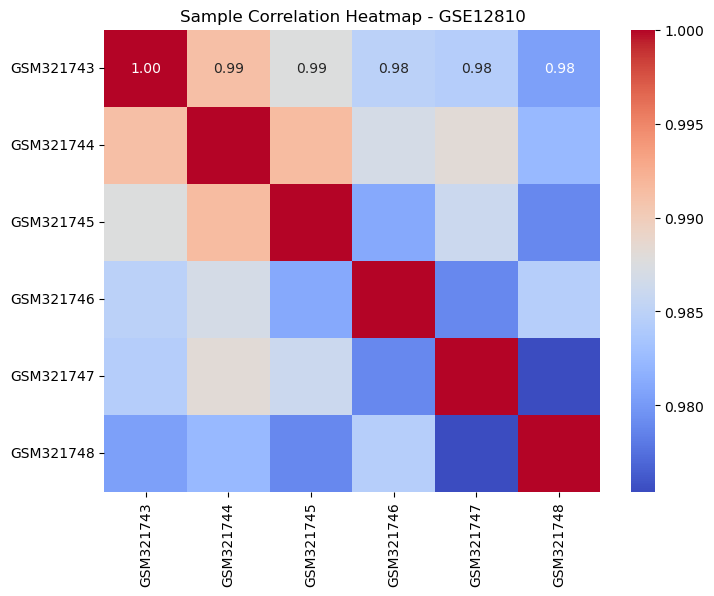

In [12]:
# ----------------------------
# Sample correlation heatmap
# ----------------------------

sample_corr = expr_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    sample_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Sample Correlation Heatmap - GSE12810")
plt.show()

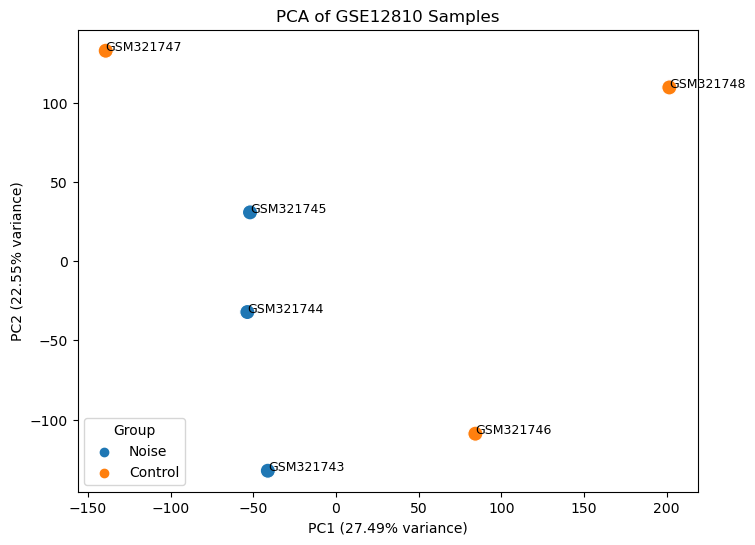

In [13]:
# ----------------------------
# PCA Analysis
# ----------------------------

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Transpose so samples are rows
expr_transposed = expr_df.T

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(expr_transposed)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Create PCA dataframe
pca_df = pd.DataFrame({
    "PC1": pca_result[:,0],
    "PC2": pca_result[:,1],
    "Group": ["Noise"]*3 + ["Control"]*3,
    "Sample": expr_transposed.index
})

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Group",
    s=120
)

for i in range(len(pca_df)):
    plt.text(
        pca_df["PC1"][i],
        pca_df["PC2"][i],
        pca_df["Sample"][i],
        fontsize=9
    )

plt.title("PCA of GSE12810 Samples")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")

plt.show()

In [14]:
# ----------------------------
# Differential Expression Analysis
# ----------------------------

results = []

for probe in expr_df.index:
    
    noise_vals = expr_df.loc[probe, noise_samples]
    control_vals = expr_df.loc[probe, control_samples]
    
    # t-test
    t_stat, p_val = stats.ttest_ind(
        noise_vals,
        control_vals,
        equal_var=False
    )
    
    # log2 fold change
    log2fc = noise_vals.mean() - control_vals.mean()
    
    results.append({
        "Probe_ID": probe,
        "Noise_Mean": noise_vals.mean(),
        "Control_Mean": control_vals.mean(),
        "Log2FC": log2fc,
        "p_value": p_val
    })

# Create dataframe
de_results = pd.DataFrame(results)

# Multiple testing correction
de_results["adj_p_value"] = multipletests(
    de_results["p_value"],
    method="fdr_bh"
)[1]

# Sort by significance
de_results = de_results.sort_values("p_value")

print("Differential expression analysis complete.")
print("Number of probes analyzed:", len(de_results))

de_results.head(10)

C:\Users\dhrub\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\dhrub\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\dhrub\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Differential expression analysis complete.
Number of probes analyzed: 45101


,Probe_ID,Noise_Mean,Control_Mean,Log2FC,p_value,adj_p_value
41240,1456946_at,3.260346,3.695002,-0.434656,0.000018,0.791054
34905,1450611_at,2.339523,2.473516,-0.133992,0.000118,0.932848
26732,1442427_at,6.590605,7.829597,-1.238992,0.000140,0.932848
26578,1442273_at,2.883873,3.399030,-0.515157,0.000170,0.932848
32196,1447891_at,6.527078,7.361273,-0.834195,0.000200,0.932848
30439,1446134_at,3.771241,4.453043,-0.681803,0.000276,0.932848
16700,1432395_at,2.702816,3.024370,-0.321554,0.000358,0.932848
8376,1424071_s_at,9.644382,9.534454,0.109928,0.000373,0.932848
14519,1430214_a_at,6.259856,5.371261,0.888595,0.000379,0.932848
25552,1441247_at,5.548050,6.332593,-0.784544,0.000409,0.932848


In [15]:
# ----------------------------
# Significant genes summary
# ----------------------------

significant = de_results[
    (de_results["adj_p_value"] < 0.05) &
    (abs(de_results["Log2FC"]) > 0.5)
]

print("Significant probes:", len(significant))

significant.head(20)

Significant probes: 0


,Probe_ID,Noise_Mean,Control_Mean,Log2FC,p_value,adj_p_value


In [16]:
# ----------------------------
# Access platform annotation
# ----------------------------

gpl = list(gse.gpls.values())[0]

print("Platform:", gpl.name)

Platform: GPL1261


In [17]:
# ----------------------------
# View annotation columns
# ----------------------------

gpl.table.columns

Index(['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Target Description',
       'Representative Public ID', 'Gene Title', 'Gene Symbol',
       'ENTREZ_GENE_ID', 'RefSeq Transcript ID',
       'Gene Ontology Biological Process', 'Gene Ontology Cellular Component',
       'Gene Ontology Molecular Function'],
      dtype='object')

In [18]:
# ----------------------------
# Prepare GPL1261 annotation table
# ----------------------------

annotation_df = gpl.table.copy()

# Keep useful annotation columns
annotation_df = annotation_df[
    [
        "ID",
        "Gene Symbol",
        "Gene Title",
        "ENTREZ_GENE_ID",
        "Gene Ontology Biological Process",
        "Gene Ontology Molecular Function",
        "Gene Ontology Cellular Component"
    ]
].copy()

# Rename ID column to match DE results
annotation_df = annotation_df.rename(columns={"ID": "Probe_ID"})

print("Annotation table shape:", annotation_df.shape)
annotation_df.head()

Annotation table shape: (45101, 7)


,Probe_ID,Gene Symbol,Gene Title,ENTREZ_GENE_ID,Gene Ontology Biological Process,Gene Ontology Molecular Function,Gene Ontology Cellular Component
0,1415670_at,Copg1,"coatomer protein complex, subunit gamma 1",54161,0006810 // transport // inferred from electron...,0005198 // structural molecule activity // inf...,0000139 // Golgi membrane // not recorded /// ...
1,1415671_at,Atp6v0d1,"ATPase, H+ transporting, lysosomal V0 subunit D1",11972,0006200 // ATP catabolic process // inferred f...,0005515 // protein binding // inferred from el...,0005765 // lysosomal membrane // not recorded ...
2,1415672_at,Golga7,"golgi autoantigen, golgin subfamily a, 7",57437,0006893 // Golgi to plasma membrane transport ...,NaN,0000139 // Golgi membrane // not recorded /// ...
3,1415673_at,Psph,phosphoserine phosphatase,100678,0006563 // L-serine metabolic process // not r...,0000287 // magnesium ion binding // not record...,0005737 // cytoplasm // not recorded /// 00430...
4,1415674_a_at,Trappc4,trafficking protein particle complex 4,60409,0006810 // transport // inferred from electron...,0005515 // protein binding // inferred from ph...,0005622 // intracellular // inferred from elec...


In [19]:
# ----------------------------
# Merge DE results with annotation
# ----------------------------

de_annotated = de_results.merge(
    annotation_df,
    on="Probe_ID",
    how="left"
)

print("Annotated DE results shape:", de_annotated.shape)

de_annotated.head(10)

Annotated DE results shape: (45101, 12)


,Probe_ID,Noise_Mean,Control_Mean,Log2FC,p_value,adj_p_value,Gene Symbol,Gene Title,ENTREZ_GENE_ID,Gene Ontology Biological Process,Gene Ontology Molecular Function,Gene Ontology Cellular Component
0,1456946_at,3.260346,3.695002,-0.434656,0.000018,0.791054,Sh3rf3,SH3 domain containing ring finger 3,237353,NaN,0005515 // protein binding // inferred from el...,NaN
1,1450611_at,2.339523,2.473516,-0.133992,0.000118,0.932848,Orm3,orosomucoid 3,18407,0002682 // regulation of immune system process...,NaN,0005576 // extracellular region // inferred fr...
2,1442427_at,6.590605,7.829597,-1.238992,0.000140,0.932848,NaN,NaN,NaN,NaN,NaN,NaN
3,1442273_at,2.883873,3.399030,-0.515157,0.000170,0.932848,Ccdc158,coiled-coil domain containing 158,320696,NaN,NaN,NaN
4,1447891_at,6.527078,7.361273,-0.834195,0.000200,0.932848,NaN,NaN,NaN,NaN,NaN,NaN
5,1446134_at,3.771241,4.453043,-0.681803,0.000276,0.932848,C78115,expressed sequence C78115,97956,NaN,NaN,NaN
6,1432395_at,2.702816,3.024370,-0.321554,0.000358,0.932848,1700039E15Rik,RIKEN cDNA 1700039E15 gene,76713,0006810 // transport // inferred from electron...,0005328 // neurotransmitter:sodium symporter a...,0016020 // membrane // inferred from electroni...
7,1424071_s_at,9.644382,9.534454,0.109928,0.000373,0.932848,Ice1,interactor of little elongation complex ELL su...,218333,NaN,NaN,NaN
8,1430214_a_at,6.259856,5.371261,0.888595,0.000379,0.932848,2610020H08Rik,RIKEN cDNA 2610020H08 gene,434234,0090305 // nucleic acid phosphodiester bond hy...,0000166 // nucleotide binding // inferred from...,0005730 // nucleolus // not recorded /// 00700...
9,1441247_at,5.548050,6.332593,-0.784544,0.000409,0.932848,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# ----------------------------
# Clean gene symbol column
# ----------------------------

de_annotated["Gene Symbol"] = de_annotated["Gene Symbol"].replace("", np.nan)

# Count annotated vs unannotated probes
annotated_count = de_annotated["Gene Symbol"].notna().sum()
unannotated_count = de_annotated["Gene Symbol"].isna().sum()

print("Annotated probes:", annotated_count)
print("Unannotated probes:", unannotated_count)

de_annotated.head(10)

Annotated probes: 39666
Unannotated probes: 5435


,Probe_ID,Noise_Mean,Control_Mean,Log2FC,p_value,adj_p_value,Gene Symbol,Gene Title,ENTREZ_GENE_ID,Gene Ontology Biological Process,Gene Ontology Molecular Function,Gene Ontology Cellular Component
0,1456946_at,3.260346,3.695002,-0.434656,0.000018,0.791054,Sh3rf3,SH3 domain containing ring finger 3,237353,NaN,0005515 // protein binding // inferred from el...,NaN
1,1450611_at,2.339523,2.473516,-0.133992,0.000118,0.932848,Orm3,orosomucoid 3,18407,0002682 // regulation of immune system process...,NaN,0005576 // extracellular region // inferred fr...
2,1442427_at,6.590605,7.829597,-1.238992,0.000140,0.932848,NaN,NaN,NaN,NaN,NaN,NaN
3,1442273_at,2.883873,3.399030,-0.515157,0.000170,0.932848,Ccdc158,coiled-coil domain containing 158,320696,NaN,NaN,NaN
4,1447891_at,6.527078,7.361273,-0.834195,0.000200,0.932848,NaN,NaN,NaN,NaN,NaN,NaN
5,1446134_at,3.771241,4.453043,-0.681803,0.000276,0.932848,C78115,expressed sequence C78115,97956,NaN,NaN,NaN
6,1432395_at,2.702816,3.024370,-0.321554,0.000358,0.932848,1700039E15Rik,RIKEN cDNA 1700039E15 gene,76713,0006810 // transport // inferred from electron...,0005328 // neurotransmitter:sodium symporter a...,0016020 // membrane // inferred from electroni...
7,1424071_s_at,9.644382,9.534454,0.109928,0.000373,0.932848,Ice1,interactor of little elongation complex ELL su...,218333,NaN,NaN,NaN
8,1430214_a_at,6.259856,5.371261,0.888595,0.000379,0.932848,2610020H08Rik,RIKEN cDNA 2610020H08 gene,434234,0090305 // nucleic acid phosphodiester bond hy...,0000166 // nucleotide binding // inferred from...,0005730 // nucleolus // not recorded /// 00700...
9,1441247_at,5.548050,6.332593,-0.784544,0.000409,0.932848,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# ----------------------------
# Save annotated DE results
# ----------------------------

de_annotated.to_csv(
    os.path.join(output_dir, "GSE12810_DE_results_annotated.csv"),
    index=False
)

print("Annotated DE results saved.")

Annotated DE results saved.


In [22]:
# ----------------------------
# Relaxed ranked DEG table
# For validation-oriented interpretation
# ----------------------------

ranked_degs = de_annotated[
    (de_annotated["p_value"] < 0.05) &
    (abs(de_annotated["Log2FC"]) > 0.3) &
    (de_annotated["Gene Symbol"].notna())
].copy()

ranked_degs = ranked_degs.sort_values("p_value")

print("Relaxed ranked DE probes:", len(ranked_degs))

ranked_degs[
    [
        "Probe_ID",
        "Gene Symbol",
        "Gene Title",
        "Log2FC",
        "p_value",
        "adj_p_value"
    ]
].head(25)

Relaxed ranked DE probes: 996


,Probe_ID,Gene Symbol,Gene Title,Log2FC,p_value,adj_p_value
0,1456946_at,Sh3rf3,SH3 domain containing ring finger 3,-0.434656,0.000018,0.791054
3,1442273_at,Ccdc158,coiled-coil domain containing 158,-0.515157,0.000170,0.932848
5,1446134_at,C78115,expressed sequence C78115,-0.681803,0.000276,0.932848
6,1432395_at,1700039E15Rik,RIKEN cDNA 1700039E15 gene,-0.321554,0.000358,0.932848
8,1430214_a_at,2610020H08Rik,RIKEN cDNA 2610020H08 gene,0.888595,0.000379,0.932848
10,1439894_at,A730056I06Rik,RIKEN cDNA A730056I06 gene,0.424204,0.000422,0.932848
11,1423677_at,Fkbp9,FK506 binding protein 9,0.518125,0.000457,0.932848
12,1438187_at,Slc25a29,solute carrier family 25 (mitochondrial carrie...,0.351928,0.000555,0.932848
14,1421173_at,Irf4,interferon regulatory factor 4,-1.093334,0.000603,0.932848
16,1449942_a_at,Ilk,integrin linked kinase,0.395216,0.000703,0.932848


In [23]:
# ----------------------------
# Save relaxed ranked DEG table
# ----------------------------

ranked_degs.to_csv(
    os.path.join(output_dir, "GSE12810_relaxed_ranked_DEGs.csv"),
    index=False
)

print("Relaxed ranked DEG table saved.")

Relaxed ranked DEG table saved.


In [24]:
# ----------------------------
# Dataset 1 candidate gene validation in GSE12810
# ----------------------------

dataset1_candidates = [
    "Hspa1b",
    "Dnm1l",
    "Stat1",
    "Gls",
    "Dnaja2",
    "Hnrnpu",
    "Pde3b",
    "Srsf1"
]

candidate_hits = []

for gene in dataset1_candidates:
    matches = de_annotated[
        de_annotated["Gene Symbol"]
        .fillna("")
        .str.contains(gene, case=False, regex=False)
    ].copy()
    
    if len(matches) > 0:
        matches["Dataset1_Candidate"] = gene
        candidate_hits.append(matches)

candidate_validation = pd.concat(candidate_hits, ignore_index=True)

candidate_validation = candidate_validation.sort_values(
    ["Dataset1_Candidate", "p_value"]
)

candidate_validation[
    [
        "Dataset1_Candidate",
        "Probe_ID",
        "Gene Symbol",
        "Gene Title",
        "Log2FC",
        "p_value",
        "adj_p_value"
    ]
]

,Dataset1_Candidate,Probe_ID,Gene Symbol,Gene Title,Log2FC,p_value,adj_p_value
17,Dnaja2,1457233_at,AK163592 /// Dnaja2,"Mus musculus adult retina cDNA, RIKEN full-len...",0.218887,0.285321,0.932848
18,Dnaja2,1429476_s_at,Dnaja2,"DnaJ (Hsp40) homolog, subfamily A, member 2",0.040843,0.794769,0.972209
19,Dnaja2,1417182_at,Dnaja2,"DnaJ (Hsp40) homolog, subfamily A, member 2",-0.031110,0.841156,0.977944
20,Dnaja2,1417183_at,Dnaja2,"DnaJ (Hsp40) homolog, subfamily A, member 2",-0.030269,0.871563,0.981625
3,Dnm1l,1428086_at,Dnm1l,dynamin 1-like,0.273567,0.220453,0.932848
4,Dnm1l,1428008_at,Dnm1l,dynamin 1-like,-0.205259,0.541825,0.939997
5,Dnm1l,1428087_at,Dnm1l,dynamin 1-like,0.027277,0.843494,0.978182
6,Dnm1l,1452638_s_at,Dnm1l,dynamin 1-like,-0.056616,0.903908,0.985703
11,Gls,1438827_at,Gls,glutaminase,0.141196,0.090063,0.932848
12,Gls,1435245_at,Gls2,"glutaminase 2 (liver, mitochondrial)",0.200213,0.374221,0.932848


In [25]:
# ----------------------------
# Save candidate validation table
# ----------------------------

candidate_validation.to_csv(
    os.path.join(output_dir, "GSE12810_Dataset1_candidate_validation.csv"),
    index=False
)

print("Candidate validation table saved.")
print("Candidate probe hits:", len(candidate_validation))
print("Candidate genes found:", candidate_validation["Dataset1_Candidate"].nunique())

Candidate validation table saved.
Candidate probe hits: 46
Candidate genes found: 8


In [26]:
# ----------------------------
# Best probe per Dataset 1 candidate gene
# ----------------------------

best_candidate_validation = (
    candidate_validation
    .sort_values("p_value")
    .groupby("Dataset1_Candidate", as_index=False)
    .first()
)

best_candidate_validation = best_candidate_validation[
    [
        "Dataset1_Candidate",
        "Probe_ID",
        "Gene Symbol",
        "Gene Title",
        "Log2FC",
        "p_value",
        "adj_p_value"
    ]
]

best_candidate_validation

,Dataset1_Candidate,Probe_ID,Gene Symbol,Gene Title,Log2FC,p_value,adj_p_value
0,Dnaja2,1457233_at,AK163592 /// Dnaja2,"Mus musculus adult retina cDNA, RIKEN full-len...",0.218887,0.285321,0.932848
1,Dnm1l,1428086_at,Dnm1l,dynamin 1-like,0.273567,0.220453,0.932848
2,Gls,1438827_at,Gls,glutaminase,0.141196,0.090063,0.932848
3,Hnrnpu,1434551_at,Hnrnpul2,heterogeneous nuclear ribonucleoprotein U-like 2,0.063787,0.031246,0.932848
4,Hspa1b,1427126_at,Hspa1b,heat shock protein 1B,0.476502,0.129344,0.932848
5,Pde3b,1433694_at,Pde3b,"phosphodiesterase 3B, cGMP-inhibited",-0.097846,0.603912,0.945868
6,Srsf1,1434972_x_at,LOC102641923 /// Srsf1,serine/arginine-rich splicing factor 1-like //...,-0.175667,0.140910,0.932848
7,Stat1,1440481_at,Stat1,signal transducer and activator of transcripti...,-1.182340,0.067314,0.932848


In [27]:
# ----------------------------
# Save best candidate validation table
# ----------------------------

best_candidate_validation.to_csv(
    os.path.join(output_dir, "GSE12810_best_candidate_validation.csv"),
    index=False
)

print("Best candidate validation table saved.")

Best candidate validation table saved.


In [28]:
# ----------------------------
# Add validation interpretation labels
# ----------------------------

def validation_label(row):
    if row["p_value"] < 0.05 and abs(row["Log2FC"]) > 0.3:
        return "Strong validation trend"
    elif row["p_value"] < 0.05:
        return "Statistical trend only"
    elif abs(row["Log2FC"]) > 0.3:
        return "Fold-change trend only"
    else:
        return "Weak/no validation trend"

best_candidate_validation["Validation_Label"] = best_candidate_validation.apply(
    validation_label,
    axis=1
)

best_candidate_validation

,Dataset1_Candidate,Probe_ID,Gene Symbol,Gene Title,Log2FC,p_value,adj_p_value,Validation_Label
0,Dnaja2,1457233_at,AK163592 /// Dnaja2,"Mus musculus adult retina cDNA, RIKEN full-len...",0.218887,0.285321,0.932848,Weak/no validation trend
1,Dnm1l,1428086_at,Dnm1l,dynamin 1-like,0.273567,0.220453,0.932848,Weak/no validation trend
2,Gls,1438827_at,Gls,glutaminase,0.141196,0.090063,0.932848,Weak/no validation trend
3,Hnrnpu,1434551_at,Hnrnpul2,heterogeneous nuclear ribonucleoprotein U-like 2,0.063787,0.031246,0.932848,Statistical trend only
4,Hspa1b,1427126_at,Hspa1b,heat shock protein 1B,0.476502,0.129344,0.932848,Fold-change trend only
5,Pde3b,1433694_at,Pde3b,"phosphodiesterase 3B, cGMP-inhibited",-0.097846,0.603912,0.945868,Weak/no validation trend
6,Srsf1,1434972_x_at,LOC102641923 /// Srsf1,serine/arginine-rich splicing factor 1-like //...,-0.175667,0.140910,0.932848,Weak/no validation trend
7,Stat1,1440481_at,Stat1,signal transducer and activator of transcripti...,-1.182340,0.067314,0.932848,Fold-change trend only


In [29]:
best_candidate_validation.to_csv(
    os.path.join(output_dir, "GSE12810_best_candidate_validation_labeled.csv"),
    index=False
)

print("Labeled candidate validation table saved.")

Labeled candidate validation table saved.


In [30]:
# ----------------------------
# Oxidative stress / Nrf2 pathway candidate validation
# ----------------------------

oxidative_stress_genes = [
    # Core Nrf2 pathway / antioxidant genes
    "Nfe2l2", "Keap1", "Hmox1", "Nqo1", "Gclc", "Gclm",
    "Gsta1", "Gsta2", "Gstm1", "Gstm2", "Gstp1",
    
    # ROS detoxification / antioxidant defense
    "Sod1", "Sod2", "Cat", "Gpx1", "Gpx3", "Gpx4",
    "Prdx1", "Prdx2", "Prdx3", "Prdx5", "Txn1", "Txn2", "Txnrd1",
    
    # Mitochondrial stress / apoptosis / redox-linked genes
    "Dnm1l", "Bax", "Bak1", "Bcl2", "Casp3", "Casp9",
    "Pink1", "Park2", "Sirt1", "Sirt3",
    
    # Inflammatory / stress-response genes
    "Stat1", "Jun", "Fos", "Irf1", "Irf4", "Nfkb1", "Tnf", "Il6",
    
    # Heat shock / chaperone stress response
    "Hspa1a", "Hspa1b", "Hsp90aa1", "Dnaja1", "Dnaja2", "Hspb1"
]

oxidative_hits = []

for gene in oxidative_stress_genes:
    matches = de_annotated[
        de_annotated["Gene Symbol"]
        .fillna("")
        .str.contains(gene, case=False, regex=False)
    ].copy()
    
    if len(matches) > 0:
        matches["Target_Gene"] = gene
        oxidative_hits.append(matches)

oxidative_validation = pd.concat(oxidative_hits, ignore_index=True)

oxidative_validation = oxidative_validation.sort_values(
    ["Target_Gene", "p_value"]
)

print("Oxidative stress/Nrf2-related probe hits:", len(oxidative_validation))
print("Unique target genes found:", oxidative_validation["Target_Gene"].nunique())

oxidative_validation[
    [
        "Target_Gene",
        "Probe_ID",
        "Gene Symbol",
        "Gene Title",
        "Log2FC",
        "p_value",
        "adj_p_value"
    ]
].head(50)

Oxidative stress/Nrf2-related probe hits: 280
Unique target genes found: 48


,Target_Gene,Probe_ID,Gene Symbol,Gene Title,Log2FC,p_value,adj_p_value
111,Bak1,1418991_at,Bak1,BCL2-antagonist/killer 1,0.251963,0.319434,0.932848
112,Bak1,1425716_s_at,Bak1,BCL2-antagonist/killer 1,0.066984,0.748721,0.966017
110,Bax,1416837_at,Bax,BCL2-associated X protein,0.121572,0.064965,0.932848
113,Bcl2,1428865_at,Bcl2l12,BCL2-like 12 (proline rich),-0.322736,0.012620,0.932848
114,Bcl2,1435449_at,Bcl2l11,BCL2-like 11 (apoptosis facilitator),0.429680,0.038090,0.932848
115,Bcl2,1435448_at,Bcl2l11,BCL2-like 11 (apoptosis facilitator),0.318377,0.134472,0.932848
116,Bcl2,1430454_x_at,Bcl2l2,BCL2-like 2,-0.261716,0.139657,0.932848
117,Bcl2,1423572_at,Bcl2l2,BCL2-like 2,0.259393,0.164660,0.932848
118,Bcl2,1422938_at,Bcl2,B cell leukemia/lymphoma 2,-0.351253,0.212592,0.932848
119,Bcl2,1450812_at,Bcl2a1a /// Bcl2a1b /// Bcl2a1c /// Bcl2a1d,B cell leukemia/lymphoma 2 related protein A1a...,0.279893,0.259859,0.932848


In [31]:
# ----------------------------
# Best probe per oxidative stress / Nrf2 gene
# ----------------------------

best_oxidative_validation = (
    oxidative_validation
    .sort_values("p_value")
    .groupby("Target_Gene", as_index=False)
    .first()
)

best_oxidative_validation = best_oxidative_validation[
    [
        "Target_Gene",
        "Probe_ID",
        "Gene Symbol",
        "Gene Title",
        "Log2FC",
        "p_value",
        "adj_p_value"
    ]
]

best_oxidative_validation = best_oxidative_validation.sort_values("p_value")

best_oxidative_validation.head(50)

,Target_Gene,Probe_ID,Gene Symbol,Gene Title,Log2FC,p_value,adj_p_value
27,Irf4,1421173_at,Irf4,interferon regulatory factor 4,-1.093334,0.000603,0.932848
28,Jun,1417409_at,Jun,jun proto-oncogene,0.455094,0.000851,0.932848
44,Tnf,1416273_at,Tnfaip2,"tumor necrosis factor, alpha-induced protein 2",0.409450,0.005537,0.932848
2,Bcl2,1428865_at,Bcl2l12,BCL2-like 12 (proline rich),-0.322736,0.012620,0.932848
25,Il6,1452843_at,Il6st,interleukin 6 signal transducer,0.317878,0.018358,0.932848
41,Sod1,1447761_x_at,Sod1,"superoxide dismutase 1, soluble",0.100968,0.030882,0.932848
24,Hspb1,1425935_at,Hspb11,"heat shock protein family B (small), member 11",-0.540068,0.034516,0.932848
5,Cat,1416429_a_at,Cat,catalase,-0.228040,0.050582,0.932848
35,Prdx1,1416000_a_at,Gm21399 /// Prdx1,peroxiredoxin 1 pseudogene /// peroxiredoxin 1,0.174780,0.055135,0.932848
1,Bax,1416837_at,Bax,BCL2-associated X protein,0.121572,0.064965,0.932848


In [32]:
# ----------------------------
# Add validation labels
# ----------------------------

best_oxidative_validation["Validation_Label"] = best_oxidative_validation.apply(
    validation_label,
    axis=1
)

best_oxidative_validation.head(50)

,Target_Gene,Probe_ID,Gene Symbol,Gene Title,Log2FC,p_value,adj_p_value,Validation_Label
27,Irf4,1421173_at,Irf4,interferon regulatory factor 4,-1.093334,0.000603,0.932848,Strong validation trend
28,Jun,1417409_at,Jun,jun proto-oncogene,0.455094,0.000851,0.932848,Strong validation trend
44,Tnf,1416273_at,Tnfaip2,"tumor necrosis factor, alpha-induced protein 2",0.409450,0.005537,0.932848,Strong validation trend
2,Bcl2,1428865_at,Bcl2l12,BCL2-like 12 (proline rich),-0.322736,0.012620,0.932848,Strong validation trend
25,Il6,1452843_at,Il6st,interleukin 6 signal transducer,0.317878,0.018358,0.932848,Strong validation trend
41,Sod1,1447761_x_at,Sod1,"superoxide dismutase 1, soluble",0.100968,0.030882,0.932848,Statistical trend only
24,Hspb1,1425935_at,Hspb11,"heat shock protein family B (small), member 11",-0.540068,0.034516,0.932848,Strong validation trend
5,Cat,1416429_a_at,Cat,catalase,-0.228040,0.050582,0.932848,Weak/no validation trend
35,Prdx1,1416000_a_at,Gm21399 /// Prdx1,peroxiredoxin 1 pseudogene /// peroxiredoxin 1,0.174780,0.055135,0.932848,Weak/no validation trend
1,Bax,1416837_at,Bax,BCL2-associated X protein,0.121572,0.064965,0.932848,Weak/no validation trend


In [33]:
# ----------------------------
# Save oxidative stress/Nrf2 validation table
# ----------------------------

best_oxidative_validation.to_csv(
    os.path.join(output_dir, "GSE12810_oxidative_stress_Nrf2_validation.csv"),
    index=False
)

print("Oxidative stress/Nrf2 validation table saved.")

Oxidative stress/Nrf2 validation table saved.


In [34]:
# ----------------------------
# Count validation categories
# ----------------------------

validation_summary = best_oxidative_validation["Validation_Label"].value_counts()

validation_summary

Validation_Label
Weak/no validation trend    31
Fold-change trend only      10
Strong validation trend      6
Statistical trend only       1
Name: count, dtype: int64

In [35]:
print("Oxidative stress/Nrf2-related probe hits:", len(oxidative_validation))
print("Unique target genes found:", oxidative_validation["Target_Gene"].nunique())

best_oxidative_validation["Validation_Label"].value_counts()

best_oxidative_validation[
    [
        "Target_Gene",
        "Gene Symbol",
        "Gene Title",
        "Log2FC",
        "p_value",
        "adj_p_value",
        "Validation_Label"
    ]
].head(25)

Oxidative stress/Nrf2-related probe hits: 280
Unique target genes found: 48


,Target_Gene,Gene Symbol,Gene Title,Log2FC,p_value,adj_p_value,Validation_Label
27,Irf4,Irf4,interferon regulatory factor 4,-1.093334,0.000603,0.932848,Strong validation trend
28,Jun,Jun,jun proto-oncogene,0.455094,0.000851,0.932848,Strong validation trend
44,Tnf,Tnfaip2,"tumor necrosis factor, alpha-induced protein 2",0.409450,0.005537,0.932848,Strong validation trend
2,Bcl2,Bcl2l12,BCL2-like 12 (proline rich),-0.322736,0.012620,0.932848,Strong validation trend
25,Il6,Il6st,interleukin 6 signal transducer,0.317878,0.018358,0.932848,Strong validation trend
41,Sod1,Sod1,"superoxide dismutase 1, soluble",0.100968,0.030882,0.932848,Statistical trend only
24,Hspb1,Hspb11,"heat shock protein family B (small), member 11",-0.540068,0.034516,0.932848,Strong validation trend
5,Cat,Cat,catalase,-0.228040,0.050582,0.932848,Weak/no validation trend
35,Prdx1,Gm21399 /// Prdx1,peroxiredoxin 1 pseudogene /// peroxiredoxin 1,0.174780,0.055135,0.932848,Weak/no validation trend
1,Bax,Bax,BCL2-associated X protein,0.121572,0.064965,0.932848,Weak/no validation trend


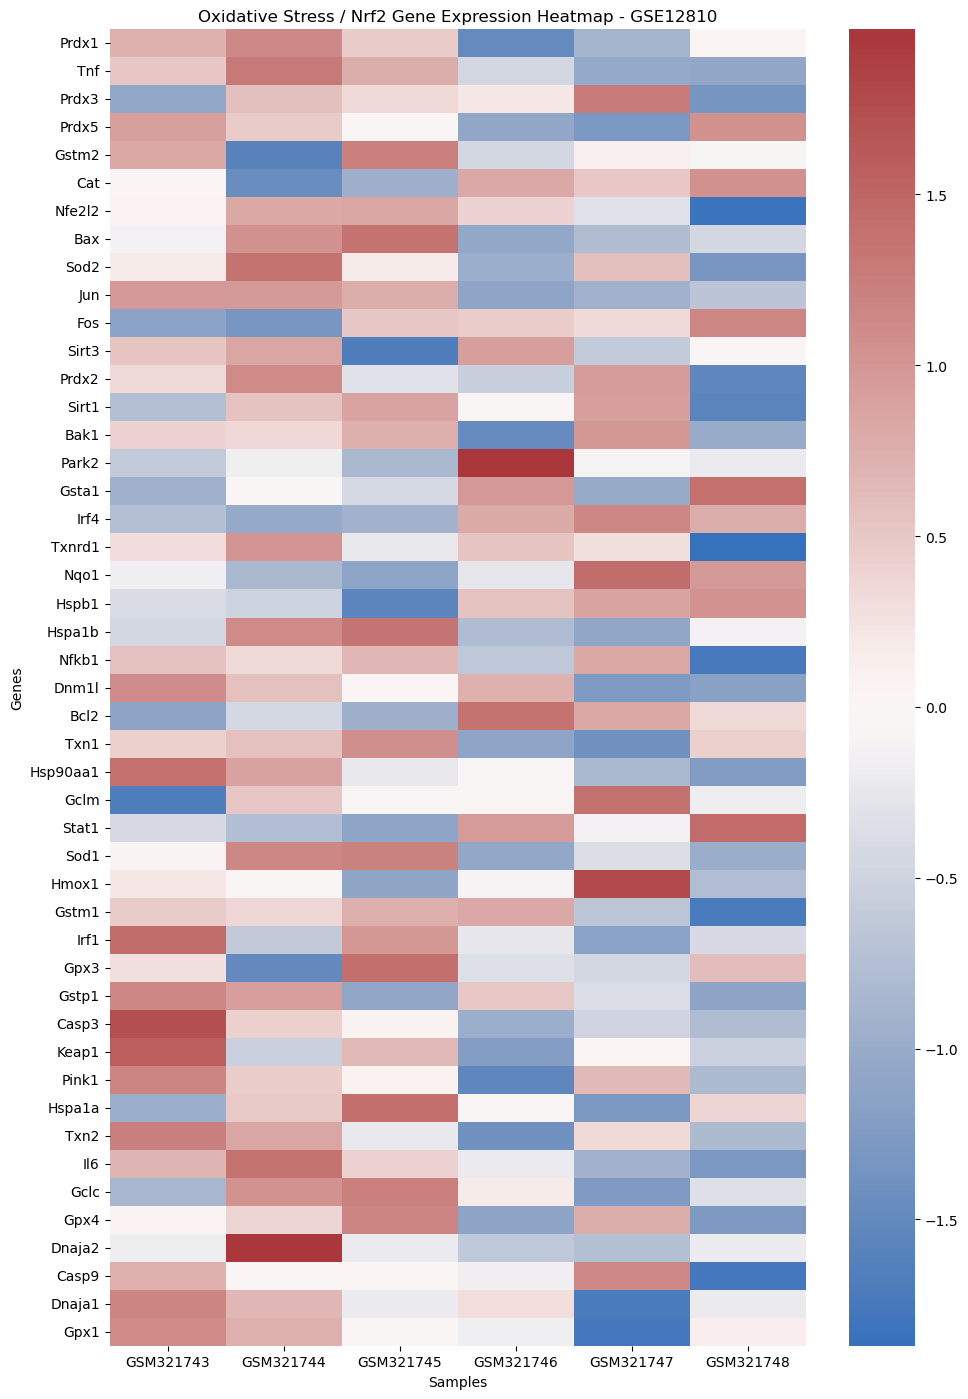

In [36]:
# ----------------------------
# Heatmap of oxidative stress / Nrf2 validation genes
# ----------------------------

# Use the best probe IDs from oxidative/Nrf2 validation
oxidative_probe_ids = best_oxidative_validation["Probe_ID"].dropna().unique()

# Subset expression matrix
oxidative_expr = expr_df.loc[expr_df.index.isin(oxidative_probe_ids)].copy()

# Add readable gene symbols as row labels
probe_to_gene = best_oxidative_validation.set_index("Probe_ID")["Target_Gene"].to_dict()
oxidative_expr.index = oxidative_expr.index.map(probe_to_gene)

# Order samples: noise first, control second
sample_order = noise_samples + control_samples
oxidative_expr = oxidative_expr[sample_order]

# Z-score by gene for heatmap visualization
oxidative_expr_z = oxidative_expr.sub(oxidative_expr.mean(axis=1), axis=0)
oxidative_expr_z = oxidative_expr_z.div(oxidative_expr.std(axis=1), axis=0)

plt.figure(figsize=(10, max(8, len(oxidative_expr_z) * 0.3)))

sns.heatmap(
    oxidative_expr_z,
    cmap="vlag",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Oxidative Stress / Nrf2 Gene Expression Heatmap - GSE12810")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.tight_layout()
plt.show()

### Oxidative Stress / Nrf2 Pathway Validation in GSE12810

Because strict FDR-adjusted differential expression was limited by the small sample size of GSE12810, oxidative stress and Nrf2-related genes were evaluated using a targeted validation approach. A total of 280 probes corresponding to 48 oxidative stress, antioxidant defense, mitochondrial stress, apoptosis, inflammatory, and heat-shock response genes were detected in the dataset.

Several genes showed strong validation trends using raw p-value and fold-change criteria, including Irf4, Jun, Tnfaip2, Bcl2l12, Il6st, and Hspb11. Additional biologically relevant genes, including Sod1, Stat1, Hspa1b, Gpx1, Nfe2l2, and Casp3, showed partial validation trends based on either statistical evidence or fold-change magnitude.

These results suggest that although GSE12810 does not produce many strict FDR-significant genes due to its small sample size, it supports a broader stress-response signature involving inflammatory signaling, antioxidant defense, apoptosis regulation, heat-shock response, and Nrf2-related oxidative stress pathways. This supports the use of GSE12810 as an independent validation dataset for pathway-level patterns identified in GSE100365.

Category
Not significant        43956
Upregulated trend        653
Downregulated trend      492
Name: count, dtype: int64


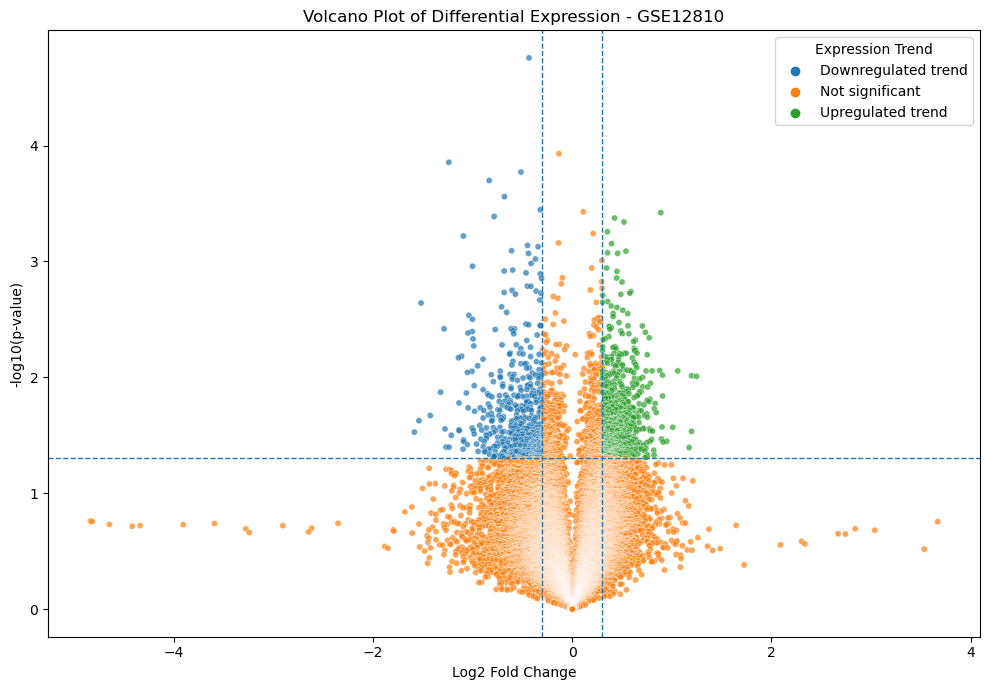

In [37]:
# ----------------------------
# Volcano plot for GSE12810
# ----------------------------

volcano_df = de_annotated.copy()

# Avoid log10 errors
volcano_df["p_value"] = volcano_df["p_value"].replace(0, np.nextafter(0, 1))

# -log10 p-value
volcano_df["neg_log10_p"] = -np.log10(volcano_df["p_value"])

# Categorize genes using relaxed validation thresholds
def volcano_category(row):
    if row["p_value"] < 0.05 and row["Log2FC"] > 0.3:
        return "Upregulated trend"
    elif row["p_value"] < 0.05 and row["Log2FC"] < -0.3:
        return "Downregulated trend"
    else:
        return "Not significant"

volcano_df["Category"] = volcano_df.apply(volcano_category, axis=1)

# Count categories
print(volcano_df["Category"].value_counts())

# Plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=volcano_df,
    x="Log2FC",
    y="neg_log10_p",
    hue="Category",
    alpha=0.7,
    s=20
)

# Threshold lines
plt.axvline(x=0.3, linestyle="--", linewidth=1)
plt.axvline(x=-0.3, linestyle="--", linewidth=1)
plt.axhline(y=-np.log10(0.05), linestyle="--", linewidth=1)

plt.title("Volcano Plot of Differential Expression - GSE12810")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(p-value)")

plt.legend(title="Expression Trend")
plt.tight_layout()
plt.show()

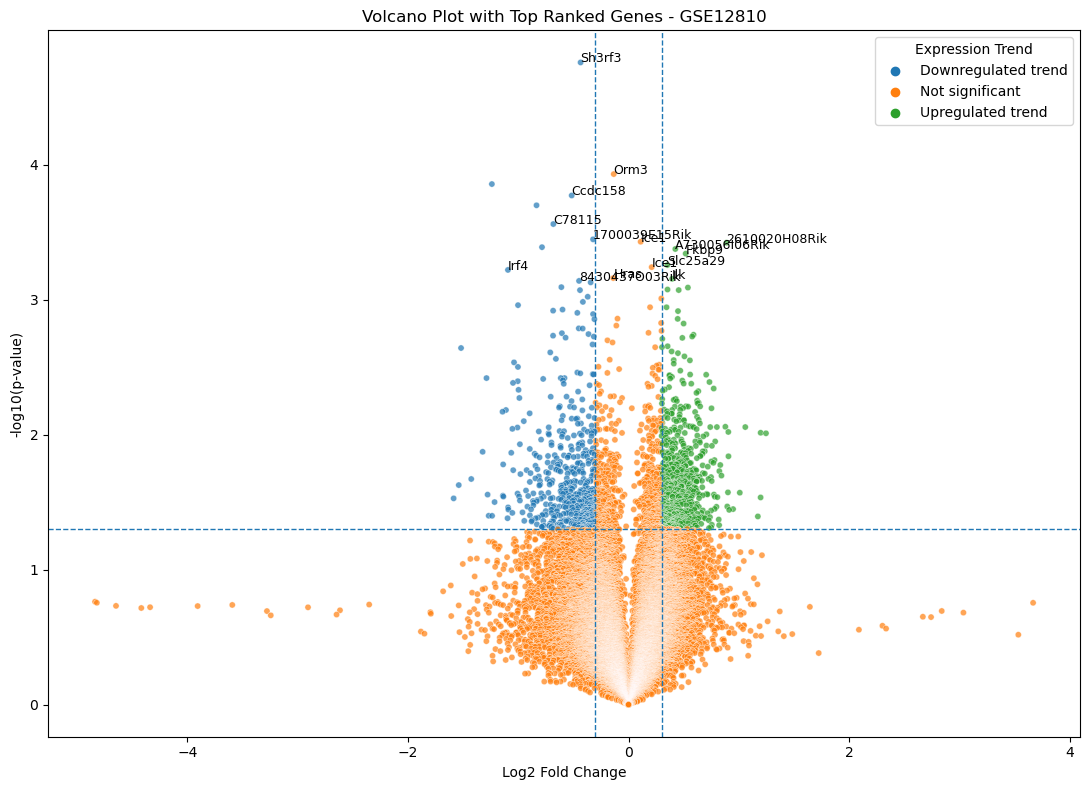

In [38]:
# ----------------------------
# Volcano plot with top gene labels
# ----------------------------

top_labeled_genes = volcano_df[
    volcano_df["Gene Symbol"].notna()
].sort_values("p_value").head(15)

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=volcano_df,
    x="Log2FC",
    y="neg_log10_p",
    hue="Category",
    alpha=0.7,
    s=20
)

plt.axvline(x=0.3, linestyle="--", linewidth=1)
plt.axvline(x=-0.3, linestyle="--", linewidth=1)
plt.axhline(y=-np.log10(0.05), linestyle="--", linewidth=1)

for _, row in top_labeled_genes.iterrows():
    plt.text(
        row["Log2FC"],
        row["neg_log10_p"],
        str(row["Gene Symbol"]),
        fontsize=9
    )

plt.title("Volcano Plot with Top Ranked Genes - GSE12810")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(p-value)")

plt.legend(title="Expression Trend")
plt.tight_layout()
plt.show()

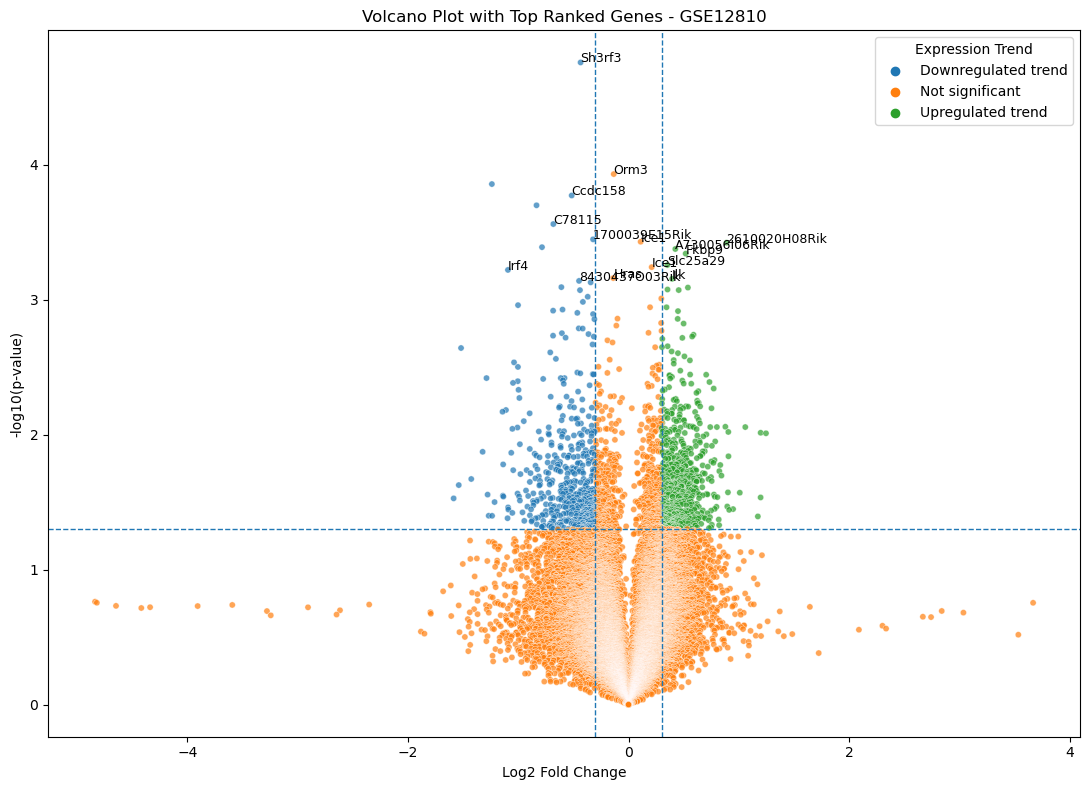

Volcano plot saved.


In [39]:
# ----------------------------
# Save volcano plot
# ----------------------------

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=volcano_df,
    x="Log2FC",
    y="neg_log10_p",
    hue="Category",
    alpha=0.7,
    s=20
)

plt.axvline(x=0.3, linestyle="--", linewidth=1)
plt.axvline(x=-0.3, linestyle="--", linewidth=1)
plt.axhline(y=-np.log10(0.05), linestyle="--", linewidth=1)

for _, row in top_labeled_genes.iterrows():
    plt.text(
        row["Log2FC"],
        row["neg_log10_p"],
        str(row["Gene Symbol"]),
        fontsize=9
    )

plt.title("Volcano Plot with Top Ranked Genes - GSE12810")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(p-value)")

plt.legend(title="Expression Trend")
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "GSE12810_volcano_plot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Volcano plot saved.")

### Volcano Plot Interpretation — GSE12810

The volcano plot shows differential-expression trends between noise-exposed and control modioli in GSE12810. Using relaxed validation thresholds of raw p-value < 0.05 and |Log2FC| > 0.3, 653 probes showed upregulated trends and 492 probes showed downregulated trends, while most probes remained near the center of the plot. Although no probes reached strict FDR-adjusted significance, the distribution of ranked expression changes suggests that noise exposure is associated with measurable transcriptomic shifts.

Because GSE12810 contains only six total samples, it is underpowered for strict genome-wide differential expression discovery. Therefore, this dataset is best interpreted as an independent validation dataset rather than a primary discovery dataset. The volcano plot supports the presence of broad but modest post-noise expression changes, which can be further interpreted through candidate-gene validation, oxidative stress/Nrf2 pathway analysis, and cross-dataset comparison with GSE100365.

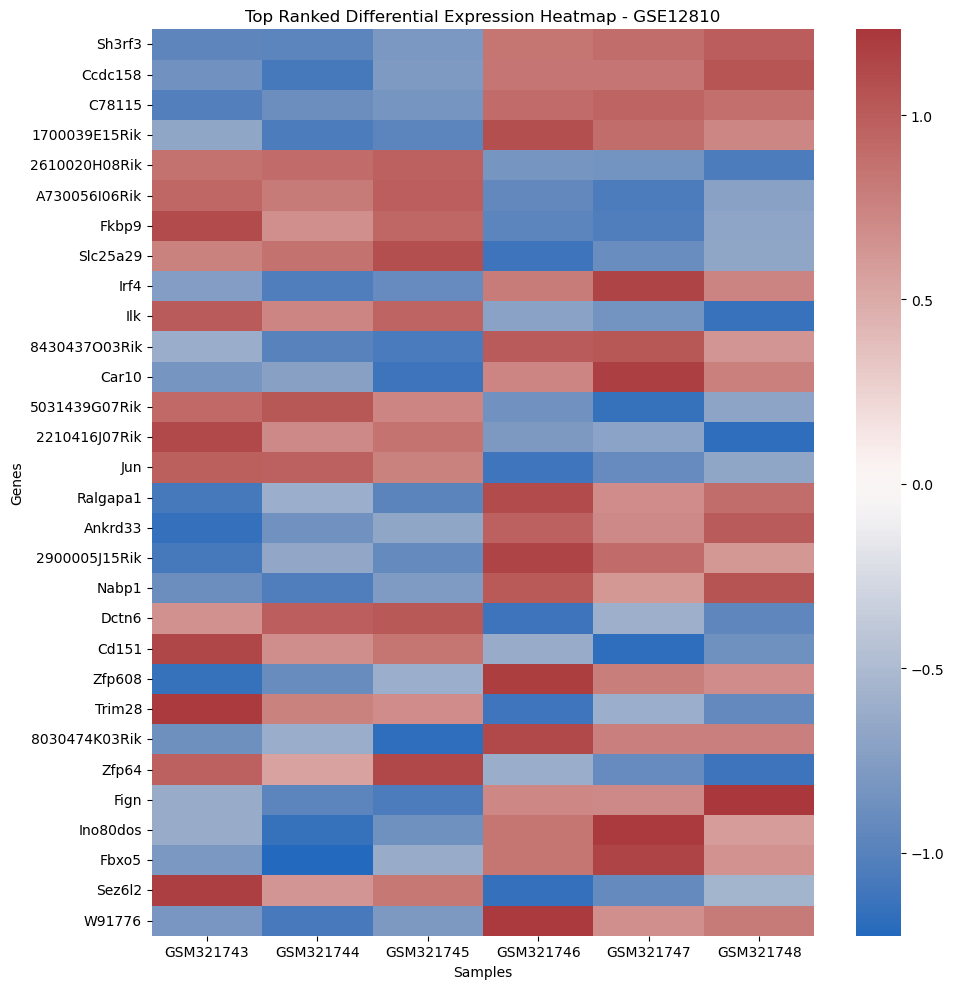

In [40]:
# ----------------------------
# Heatmap of top ranked DE genes
# ----------------------------

# Select top annotated ranked genes by p-value
top_degs = ranked_degs.sort_values("p_value").head(30).copy()

# Extract probe IDs
top_probe_ids = top_degs["Probe_ID"].tolist()

# Subset expression matrix
top_expr = expr_df.loc[top_probe_ids].copy()

# Create readable row labels using gene symbols
probe_to_gene = top_degs.set_index("Probe_ID")["Gene Symbol"].to_dict()
top_expr.index = top_expr.index.map(probe_to_gene)

# Order samples: noise first, then control
sample_order = noise_samples + control_samples
top_expr = top_expr[sample_order]

# Z-score by gene
top_expr_z = top_expr.sub(top_expr.mean(axis=1), axis=0)
top_expr_z = top_expr_z.div(top_expr.std(axis=1), axis=0)

plt.figure(figsize=(10, 10))

sns.heatmap(
    top_expr_z,
    cmap="vlag",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Top Ranked Differential Expression Heatmap - GSE12810")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.tight_layout()
plt.show()

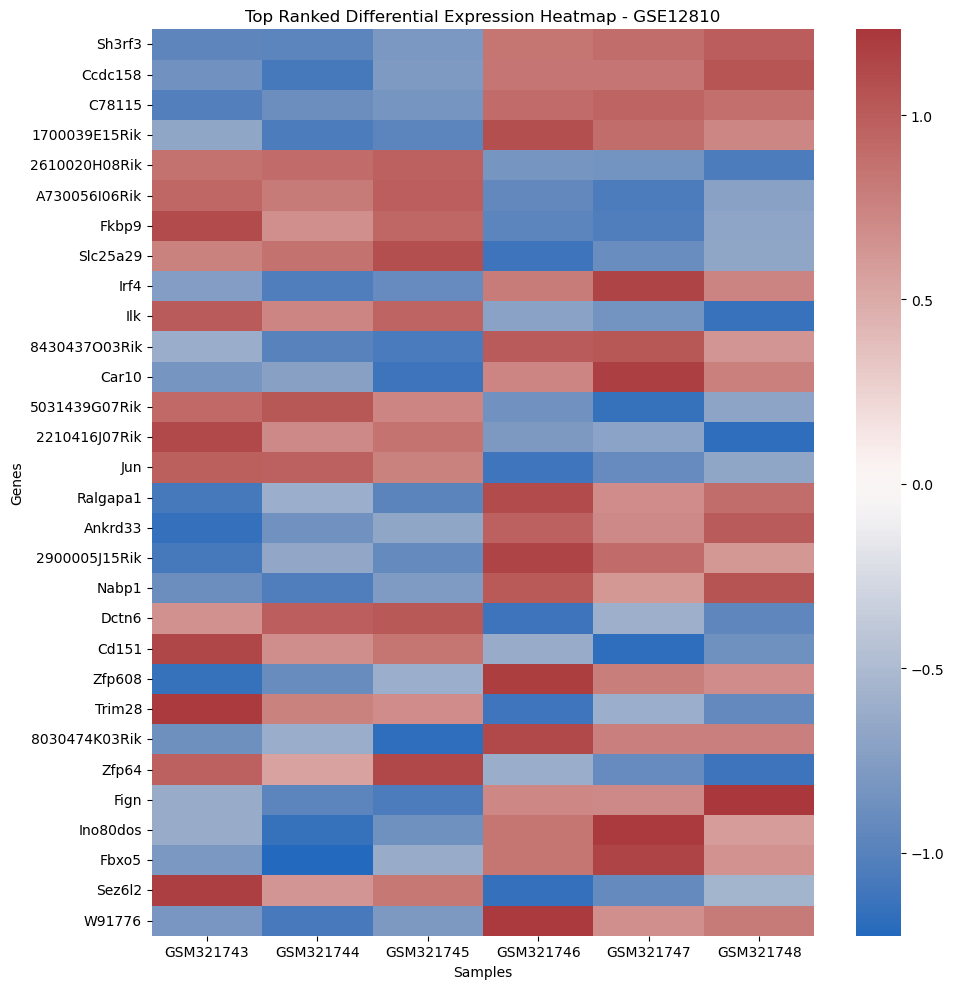

Top ranked DEG heatmap saved.


In [41]:
# ----------------------------
# Save top DEG heatmap
# ----------------------------

plt.figure(figsize=(10, 10))

sns.heatmap(
    top_expr_z,
    cmap="vlag",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Top Ranked Differential Expression Heatmap - GSE12810")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "GSE12810_top_ranked_DEG_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top ranked DEG heatmap saved.")

### Top Ranked DEG Heatmap Interpretation — GSE12810

A heatmap was generated using the top 30 annotated ranked differentially expressed probes from GSE12810. Expression values were z-score normalized by gene to visualize relative expression patterns across samples. The heatmap shows visible separation between the three noise-exposed samples and the three control samples, with many genes displaying opposite expression patterns between groups.

Although strict FDR-adjusted differential expression was limited by the small sample size, the heatmap demonstrates that the top ranked genes capture coordinated transcriptomic differences associated with noise exposure. This supports the use of GSE12810 as an independent validation dataset for identifying recurring gene-expression and stress-response patterns related to NIHL.

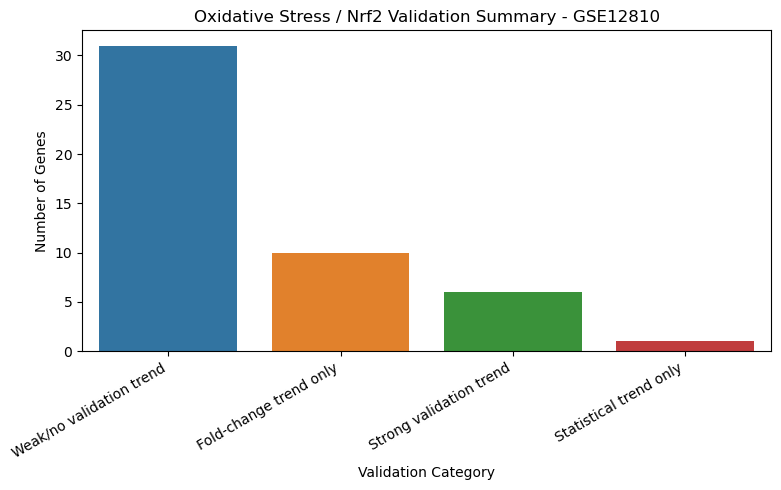

Validation_Label
Weak/no validation trend    31
Fold-change trend only      10
Strong validation trend      6
Statistical trend only       1
Name: count, dtype: int64

In [42]:
# ----------------------------
# Oxidative stress / Nrf2 validation summary bar plot
# ----------------------------

validation_counts = best_oxidative_validation["Validation_Label"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=validation_counts.index,
    y=validation_counts.values
)

plt.title("Oxidative Stress / Nrf2 Validation Summary - GSE12810")
plt.xlabel("Validation Category")
plt.ylabel("Number of Genes")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

validation_counts

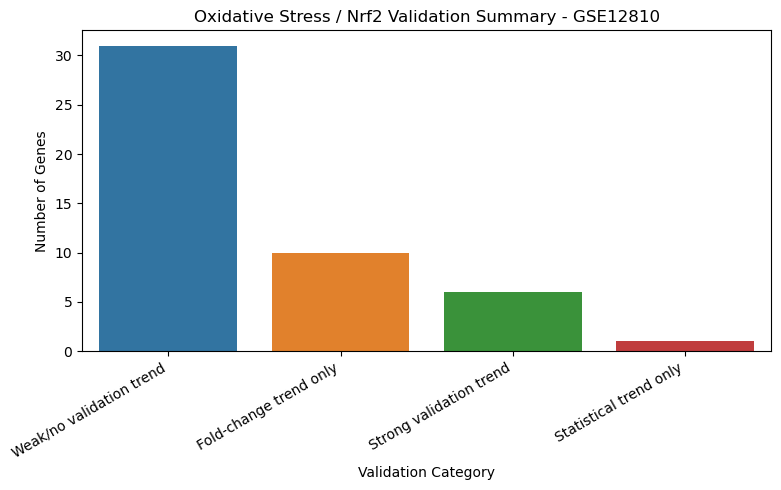

Oxidative validation summary bar plot saved.


In [43]:
# ----------------------------
# Save oxidative validation summary plot
# ----------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    x=validation_counts.index,
    y=validation_counts.values
)

plt.title("Oxidative Stress / Nrf2 Validation Summary - GSE12810")
plt.xlabel("Validation Category")
plt.ylabel("Number of Genes")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "GSE12810_oxidative_validation_summary_barplot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Oxidative validation summary bar plot saved.")

### Oxidative Stress / Nrf2 Validation Summary

A targeted oxidative stress/Nrf2 validation analysis identified 48 oxidative stress, antioxidant defense, mitochondrial stress, apoptosis, inflammatory, and heat-shock response genes in GSE12810. Of these, 6 genes showed strong validation trends, 10 showed fold-change trends only, and 1 showed a statistical trend only, while 31 showed weak or no validation trend.

These results suggest that GSE12810 provides partial pathway-level support for oxidative stress and stress-response involvement in noise-induced hearing loss. Although the majority of selected genes did not show strong differential expression, a subset of biologically relevant genes demonstrated expression changes consistent with inflammatory signaling, antioxidant response, apoptosis regulation, and cellular stress pathways. This supports the use of GSE12810 as an independent validation dataset, especially for pathway-level interpretation rather than strict genome-wide discovery.

In [45]:
# ----------------------------
# Check files in current directory
# ----------------------------

import os

os.listdir()

['-1.14-windows.xml',
 '.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.eclipse',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.p2',
 'anaconda3',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'eclipse',
 'eclipse-workspace',
 'Favorites',
 'GSE100365_gene_impact_scores.csv',
 'GSE12810_Dataset_Pipeline.ipynb',
 'GSE12810_Validation_Analysis',
 'Links',
 'Local Settings',
 'Muse Hub',
 'Music',
 'My Documents',
 'NetHood',
 'NIHL Gene Expression Analysis - Differential Expression and Bioinformatics Pipeline (GSE100365).ipynb',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{a581c316-54c2-11f0-9fdc-289200d38eba}.TM.blf',
 'NTUSER.DAT{a581c316-54c2-11f0-9fdc-289200d38eba}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{a581c316-54c2-11f0-9fdc-289200d38eba}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'Recent',
 'Saved Games'

In [53]:
# ----------------------------
# Check current working directory
# ----------------------------

import os

print(os.getcwd())

C:\Users\dhrub


In [54]:
# ----------------------------
# List files/folders in current directory
# ----------------------------

os.listdir()

['-1.14-windows.xml',
 '.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.eclipse',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.p2',
 'anaconda3',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'eclipse',
 'eclipse-workspace',
 'Favorites',
 'GSE100365_gene_impact_scores.csv',
 'GSE12810_Dataset_Pipeline.ipynb',
 'GSE12810_Validation_Analysis',
 'Links',
 'Local Settings',
 'Muse Hub',
 'Music',
 'My Documents',
 'NetHood',
 'NIHL Gene Expression Analysis - Differential Expression and Bioinformatics Pipeline (GSE100365).ipynb',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{a581c316-54c2-11f0-9fdc-289200d38eba}.TM.blf',
 'NTUSER.DAT{a581c316-54c2-11f0-9fdc-289200d38eba}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{a581c316-54c2-11f0-9fdc-289200d38eba}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'Recent',
 'Saved Games'

In [55]:
# ----------------------------
# Search current directory and subfolders for GSE100365-related files
# ----------------------------

matches = []

for root, dirs, files in os.walk("."):
    for file in files:
        if "GSE100365" in file or "100365" in file:
            matches.append(os.path.join(root, file))

matches

['.\\GSE100365_gene_impact_scores.csv',
 '.\\NIHL Gene Expression Analysis - Differential Expression and Bioinformatics Pipeline (GSE100365).ipynb',
 '.\\.ipynb_checkpoints\\NIHL Gene Expression Analysis - Differential Expression and Bioinformatics Pipeline (GSE100365)-checkpoint.ipynb',
 '.\\AppData\\Local\\Google\\Chrome\\User Data\\Profile 2\\Code Cache\\js\\0100365e7fecf93a_0',
 '.\\AppData\\Local\\Temp\\3d69e075-252a-42cc-95b7-cf256225b117_GSE100365_series_matrix.txt.gz.117\\GSE100365_series_matrix.txt',
 '.\\AppData\\Roaming\\Microsoft\\Windows\\Recent\\Dataset1_GSE100365.lnk',
 '.\\AppData\\Roaming\\Microsoft\\Windows\\Recent\\GSE100365_NIHL_Analysis_Pipeline.ipynb.lnk',
 '.\\AppData\\Roaming\\Microsoft\\Windows\\Recent\\GSE100365_series_matrix.txt (2).lnk',
 '.\\AppData\\Roaming\\Microsoft\\Windows\\Recent\\GSE100365_series_matrix.txt.lnk',
 '.\\Downloads\\GSE100365_series_matrix.txt',
 '.\\Downloads\\Tables\\GSE100365_differential_expression_results.csv',
 '.\\Downloads\\Table

In [56]:
# ----------------------------
# Load Dataset 1 GSE100365 differential expression results
# ----------------------------

dataset1_de_path = r".\OneDrive\Desktop\NIHL_Project\Dataset1_GSE100365\Tables\GSE100365_differential_expression_results.csv"

gse100365_de = pd.read_csv(dataset1_de_path)

print("GSE100365 DE results shape:", gse100365_de.shape)

gse100365_de.head()

GSE100365 DE results shape: (45101, 12)


,Probe_ID,Gene_Symbol,Gene_Title,T-stat,P-value,Control_Mean,Noise_Mean,Log2FC,Abs_Log2FC,GO:Function,GO:Process,GO:Component
0,1423050_s_at,Hnrnpu,heterogeneous nuclear ribonucleoprotein U,-10.696219,2.535651e-07,10.433333,10.700833,0.267500,0.267500,ATP binding///DNA binding///RNA binding///core...,CRD-mediated mRNA stabilization///RNA splicing...,CRD-mediated mRNA stability complex///catalyti...
1,1448556_at,Prlr,prolactin receptor,-9.925903,4.287489e-07,2.696667,3.020000,0.323333,0.323333,cytokine receptor activity///metal ion binding...,JAK-STAT cascade///activation of transmembrane...,cell surface///integral component of membrane/...
2,1452638_s_at,Dnm1l,dynamin 1-like,-8.587807,1.050781e-06,7.266667,7.611667,0.345000,0.345000,GTP binding///GTP-dependent protein binding///...,dynamin polymerization involved in mitochondri...,Golgi apparatus///brush border///cell junction...
3,1454930_at,Tbcel,tubulin folding cofactor E-like,8.597061,1.085801e-06,8.810000,8.520000,-0.290000,0.290000,molecular_function,biological_process,cellular_component///cytoplasm///cytoskeleton
4,1456161_at,0610040B10Rik,RIKEN cDNA 0610040B10 gene,9.183157,1.299282e-06,5.120000,4.606667,-0.513333,0.513333,NaN,NaN,NaN


In [57]:
# ----------------------------
# Inspect Dataset 1 columns
# ----------------------------

gse100365_de.columns

Index(['Probe_ID', 'Gene_Symbol', 'Gene_Title', 'T-stat', 'P-value',
       'Control_Mean', 'Noise_Mean', 'Log2FC', 'Abs_Log2FC', 'GO:Function',
       'GO:Process', 'GO:Component'],
      dtype='object')

In [58]:
# ----------------------------
# Standardize Dataset 1: GSE100365
# ----------------------------

gse100365_standard = gse100365_de[
    [
        "Probe_ID",
        "Gene_Symbol",
        "Gene_Title",
        "Log2FC",
        "P-value"
    ]
].copy()

gse100365_standard = gse100365_standard.rename(columns={
    "Probe_ID": "GSE100365_Probe_ID",
    "Gene_Symbol": "Gene",
    "Gene_Title": "GSE100365_Gene_Title",
    "Log2FC": "GSE100365_Log2FC",
    "P-value": "GSE100365_p_value"
})

# Clean gene names
gse100365_standard["Gene"] = gse100365_standard["Gene"].astype(str).str.strip()

# Remove empty/nan gene names
gse100365_standard = gse100365_standard[
    (gse100365_standard["Gene"].notna()) &
    (gse100365_standard["Gene"] != "") &
    (gse100365_standard["Gene"].str.lower() != "nan")
]

print("Standardized GSE100365 shape:", gse100365_standard.shape)

gse100365_standard.head()

Standardized GSE100365 shape: (39860, 5)


,GSE100365_Probe_ID,Gene,GSE100365_Gene_Title,GSE100365_Log2FC,GSE100365_p_value
0,1423050_s_at,Hnrnpu,heterogeneous nuclear ribonucleoprotein U,0.267500,2.535651e-07
1,1448556_at,Prlr,prolactin receptor,0.323333,4.287489e-07
2,1452638_s_at,Dnm1l,dynamin 1-like,0.345000,1.050781e-06
3,1454930_at,Tbcel,tubulin folding cofactor E-like,-0.290000,1.085801e-06
4,1456161_at,0610040B10Rik,RIKEN cDNA 0610040B10 gene,-0.513333,1.299282e-06


In [60]:
# ----------------------------
# Standardize Dataset 2: GSE12810
# ----------------------------

gse12810_standard = de_annotated[
    [
        "Probe_ID",
        "Gene Symbol",
        "Gene Title",
        "Log2FC",
        "p_value"
    ]
].copy()

gse12810_standard = gse12810_standard.rename(columns={
    "Probe_ID": "GSE12810_Probe_ID",
    "Gene Symbol": "Gene",
    "Gene Title": "GSE12810_Gene_Title",
    "Log2FC": "GSE12810_Log2FC",
    "p_value": "GSE12810_p_value"
})

# Clean gene names
gse12810_standard["Gene"] = gse12810_standard["Gene"].astype(str).str.strip()

# Remove empty/nan gene names
gse12810_standard = gse12810_standard[
    (gse12810_standard["Gene"].notna()) &
    (gse12810_standard["Gene"] != "") &
    (gse12810_standard["Gene"].str.lower() != "nan")
]

print("Standardized GSE12810 shape:", gse12810_standard.shape)

gse12810_standard.head()

Standardized GSE12810 shape: (39666, 5)


,GSE12810_Probe_ID,Gene,GSE12810_Gene_Title,GSE12810_Log2FC,GSE12810_p_value
0,1456946_at,Sh3rf3,SH3 domain containing ring finger 3,-0.434656,0.000018
1,1450611_at,Orm3,orosomucoid 3,-0.133992,0.000118
3,1442273_at,Ccdc158,coiled-coil domain containing 158,-0.515157,0.000170
5,1446134_at,C78115,expressed sequence C78115,-0.681803,0.000276
6,1432395_at,1700039E15Rik,RIKEN cDNA 1700039E15 gene,-0.321554,0.000358


In [61]:
# ----------------------------
# Collapse GSE100365 to best probe per gene
# ----------------------------

gse100365_best = (
    gse100365_standard
    .sort_values("GSE100365_p_value")
    .groupby("Gene", as_index=False)
    .first()
)

print("GSE100365 unique genes:", gse100365_best.shape)

gse100365_best.head()

GSE100365 unique genes: (21722, 5)


,Gene,GSE100365_Probe_ID,GSE100365_Gene_Title,GSE100365_Log2FC,GSE100365_p_value
0,0610005C13Rik,1434906_at,RIKEN cDNA 0610005C13 gene,-0.149167,0.106729
1,0610006L08Rik,1430444_at,RIKEN cDNA 0610006L08 gene,0.131667,0.406830
2,0610007P14Rik,1454161_s_at,RIKEN cDNA 0610007P14 gene,-0.003333,0.968846
3,0610009B22Rik,1418083_at,RIKEN cDNA 0610009B22 gene,0.019167,0.646950
4,0610009L18Rik,1453141_at,RIKEN cDNA 0610009L18 gene,0.030833,0.814299


In [62]:
# ----------------------------
# Collapse GSE12810 to best probe per gene
# ----------------------------

gse12810_best = (
    gse12810_standard
    .sort_values("GSE12810_p_value")
    .groupby("Gene", as_index=False)
    .first()
)

print("GSE12810 unique genes:", gse12810_best.shape)

gse12810_best.head()

GSE12810 unique genes: (21815, 5)


,Gene,GSE12810_Probe_ID,GSE12810_Gene_Title,GSE12810_Log2FC,GSE12810_p_value
0,0610005C13Rik,1434906_at,RIKEN cDNA 0610005C13 gene,0.086793,0.504128
1,0610006L08Rik,1430444_at,RIKEN cDNA 0610006L08 gene,0.066197,0.781075
2,0610007P14Rik,1454161_s_at,RIKEN cDNA 0610007P14 gene,0.018919,0.940900
3,0610009B22Rik,1418083_at,RIKEN cDNA 0610009B22 gene,-0.027252,0.872725
4,0610009L18Rik,1453141_at,RIKEN cDNA 0610009L18 gene,-0.089831,0.916173


In [63]:
# ----------------------------
# Cross-dataset gene overlap
# ----------------------------

cross_dataset = gse100365_best.merge(
    gse12810_best,
    on="Gene",
    how="inner"
)

print("Overlapping genes between GSE100365 and GSE12810:", cross_dataset.shape[0])

cross_dataset.head()

Overlapping genes between GSE100365 and GSE12810: 20226


,Gene,GSE100365_Probe_ID,GSE100365_Gene_Title,GSE100365_Log2FC,GSE100365_p_value,GSE12810_Probe_ID,GSE12810_Gene_Title,GSE12810_Log2FC,GSE12810_p_value
0,0610005C13Rik,1434906_at,RIKEN cDNA 0610005C13 gene,-0.149167,0.106729,1434906_at,RIKEN cDNA 0610005C13 gene,0.086793,0.504128
1,0610006L08Rik,1430444_at,RIKEN cDNA 0610006L08 gene,0.131667,0.406830,1430444_at,RIKEN cDNA 0610006L08 gene,0.066197,0.781075
2,0610007P14Rik,1454161_s_at,RIKEN cDNA 0610007P14 gene,-0.003333,0.968846,1454161_s_at,RIKEN cDNA 0610007P14 gene,0.018919,0.940900
3,0610009B22Rik,1418083_at,RIKEN cDNA 0610009B22 gene,0.019167,0.646950,1418083_at,RIKEN cDNA 0610009B22 gene,-0.027252,0.872725
4,0610009L18Rik,1453141_at,RIKEN cDNA 0610009L18 gene,0.030833,0.814299,1453141_at,RIKEN cDNA 0610009L18 gene,-0.089831,0.916173


In [64]:
# ----------------------------
# Direction agreement between datasets
# ----------------------------

def direction_label(fc):
    if fc > 0:
        return "Up"
    elif fc < 0:
        return "Down"
    else:
        return "No change"

cross_dataset["GSE100365_Direction"] = cross_dataset["GSE100365_Log2FC"].apply(direction_label)
cross_dataset["GSE12810_Direction"] = cross_dataset["GSE12810_Log2FC"].apply(direction_label)

cross_dataset["Direction_Agreement"] = (
    cross_dataset["GSE100365_Direction"] == cross_dataset["GSE12810_Direction"]
)

cross_dataset[
    [
        "Gene",
        "GSE100365_Log2FC",
        "GSE12810_Log2FC",
        "GSE100365_p_value",
        "GSE12810_p_value",
        "GSE100365_Direction",
        "GSE12810_Direction",
        "Direction_Agreement"
    ]
].head(25)

,Gene,GSE100365_Log2FC,GSE12810_Log2FC,GSE100365_p_value,GSE12810_p_value,GSE100365_Direction,GSE12810_Direction,Direction_Agreement
0,0610005C13Rik,-0.149167,0.086793,0.106729,0.504128,Down,Up,False
1,0610006L08Rik,0.131667,0.066197,0.406830,0.781075,Up,Up,True
2,0610007P14Rik,-0.003333,0.018919,0.968846,0.940900,Down,Up,False
3,0610009B22Rik,0.019167,-0.027252,0.646950,0.872725,Up,Down,False
4,0610009L18Rik,0.030833,-0.089831,0.814299,0.916173,Up,Down,False
5,0610009O20Rik,-0.061667,0.346689,0.265775,0.208191,Down,Up,False
6,0610010F05Rik,-0.021667,-0.206147,0.380666,0.051388,Down,Down,True
7,0610011F06Rik,0.067500,0.058473,0.109599,0.380064,Up,Up,True
8,0610012G03Rik,-0.018333,0.293149,0.772388,0.067734,Down,Up,False
9,0610025J13Rik,-0.073333,-0.213897,0.386411,0.435435,Down,Down,True


In [65]:
# ----------------------------
# Cross-dataset direction summary
# ----------------------------

agreement_counts = cross_dataset["Direction_Agreement"].value_counts()

print("Direction agreement counts:")
print(agreement_counts)

print("\nPercent agreement:")
print(cross_dataset["Direction_Agreement"].value_counts(normalize=True) * 100)

Direction agreement counts:
Direction_Agreement
True     10116
False    10110
Name: count, dtype: int64

Percent agreement:
Direction_Agreement
True     50.014832
False    49.985168
Name: proportion, dtype: float64


In [66]:
# ----------------------------
# Save cross-dataset comparison table
# ----------------------------

cross_dataset.to_csv(
    os.path.join(output_dir, "GSE100365_GSE12810_cross_dataset_gene_comparison.csv"),
    index=False
)

print("Cross-dataset comparison table saved.")

Cross-dataset comparison table saved.


In [67]:
# ----------------------------
# Cross-dataset direction summary
# ----------------------------

agreement_counts = cross_dataset["Direction_Agreement"].value_counts()

print("Direction agreement counts:")
print(agreement_counts)

print("\nPercent agreement:")
print(cross_dataset["Direction_Agreement"].value_counts(normalize=True) * 100)

Direction agreement counts:
Direction_Agreement
True     10116
False    10110
Name: count, dtype: int64

Percent agreement:
Direction_Agreement
True     50.014832
False    49.985168
Name: proportion, dtype: float64


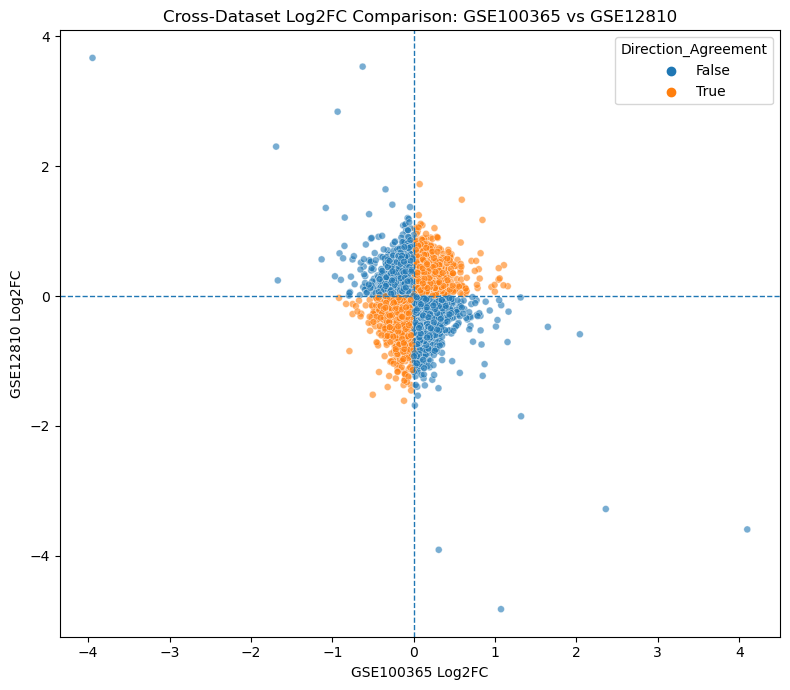

In [68]:
# ----------------------------
# Cross-dataset Log2FC scatterplot
# ----------------------------

plt.figure(figsize=(8, 7))

sns.scatterplot(
    data=cross_dataset,
    x="GSE100365_Log2FC",
    y="GSE12810_Log2FC",
    hue="Direction_Agreement",
    alpha=0.6,
    s=25
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Cross-Dataset Log2FC Comparison: GSE100365 vs GSE12810")
plt.xlabel("GSE100365 Log2FC")
plt.ylabel("GSE12810 Log2FC")

plt.tight_layout()
plt.show()

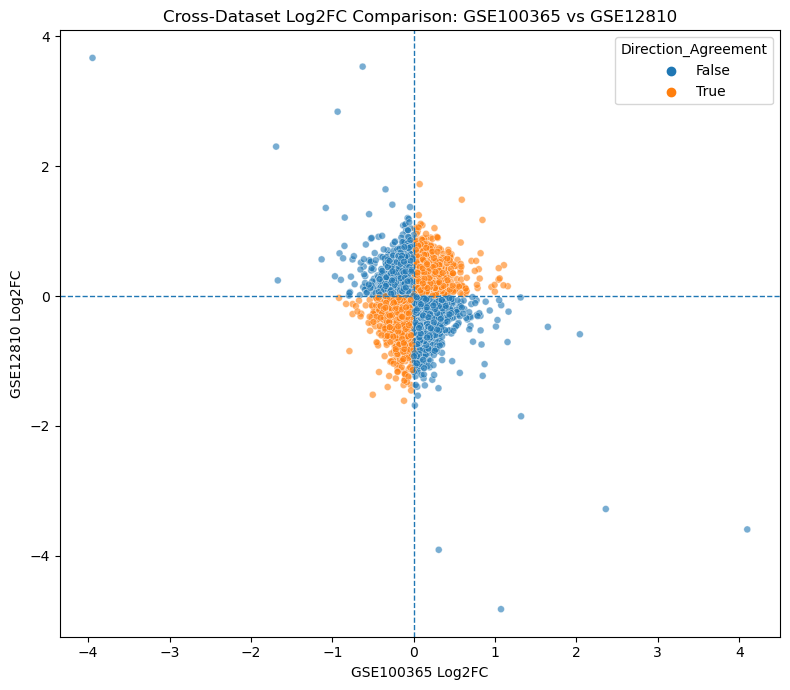

Cross-dataset Log2FC scatterplot saved.


In [70]:
# ----------------------------
# Save cross-dataset scatterplot
# ----------------------------

plt.figure(figsize=(8, 7))

sns.scatterplot(
    data=cross_dataset,
    x="GSE100365_Log2FC",
    y="GSE12810_Log2FC",
    hue="Direction_Agreement",
    alpha=0.6,
    s=25
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Cross-Dataset Log2FC Comparison: GSE100365 vs GSE12810")
plt.xlabel("GSE100365 Log2FC")
plt.ylabel("GSE12810 Log2FC")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "GSE100365_GSE12810_Log2FC_scatterplot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cross-dataset Log2FC scatterplot saved.")

### Cross-Dataset Log2FC Comparison — GSE100365 vs GSE12810

A cross-dataset comparison was performed between GSE100365 and GSE12810 by collapsing each dataset to the best probe per gene and merging by shared gene symbol. A total of 20,226 overlapping genes were identified, indicating strong platform-level comparability between the two datasets.

When comparing the direction of Log2FC values across all overlapping genes, 10,116 genes showed the same direction of change between datasets, while 10,110 genes showed opposite directions. This corresponds to approximately 50.01% directional agreement and 49.99% disagreement. Therefore, the datasets do not show strong global transcriptome-wide directional agreement.

However, this does not invalidate GSE12810 as a validation dataset. GSE100365 and GSE12810 differ in experimental context, tissue focus, and post-noise biological timing. As a result, global expression patterns may vary between datasets. The more biologically relevant validation strategy is to focus on ranked genes, candidate genes, oxidative stress/Nrf2-related genes, mitochondrial stress, inflammation, apoptosis, and heat-shock response patterns. These pathway-level analyses provide more meaningful evidence for recurring NIHL-related stress-response mechanisms than whole-transcriptome directional agreement alone.

In [71]:
# ----------------------------
# Cross-dataset comparison for oxidative stress / Nrf2 genes only
# ----------------------------

oxidative_gene_set = set(oxidative_stress_genes)

cross_oxidative = cross_dataset[
    cross_dataset["Gene"].isin(oxidative_gene_set)
].copy()

print("Oxidative stress/Nrf2 genes overlapping between datasets:", cross_oxidative.shape[0])

cross_oxidative[
    [
        "Gene",
        "GSE100365_Log2FC",
        "GSE12810_Log2FC",
        "GSE100365_p_value",
        "GSE12810_p_value",
        "GSE100365_Direction",
        "GSE12810_Direction",
        "Direction_Agreement"
    ]
].sort_values("GSE12810_p_value").head(30)

Oxidative stress/Nrf2 genes overlapping between datasets: 46


,Gene,GSE100365_Log2FC,GSE12810_Log2FC,GSE100365_p_value,GSE12810_p_value,GSE100365_Direction,GSE12810_Direction,Direction_Agreement
10508,Irf4,-0.147500,-1.093334,0.648961,0.000603,Down,Down,True
10640,Jun,0.585000,0.455094,0.008992,0.000851,Up,Up,True
17043,Sod1,-0.223333,0.100968,0.008711,0.030882,Down,Up,False
4874,Cat,0.009167,-0.228040,0.910596,0.050582,Up,Down,False
4126,Bax,-0.160833,0.121572,0.330899,0.064965,Down,Up,False
17395,Stat1,0.566667,-1.182340,0.001240,0.067314,Up,Down,False
4861,Casp3,0.145000,0.440267,0.107170,0.086258,Up,Up,True
13146,Nqo1,-0.082500,-0.254880,0.622854,0.089263,Down,Down,True
10076,Hsp90aa1,0.061667,0.229843,0.240051,0.090315,Up,Up,True
10092,Hspb1,0.008333,0.218573,0.943480,0.090927,Up,Up,True


In [72]:
# ----------------------------
# Oxidative stress/Nrf2 direction agreement summary
# ----------------------------

oxidative_agreement_counts = cross_oxidative["Direction_Agreement"].value_counts()

print("Oxidative/Nrf2 direction agreement counts:")
print(oxidative_agreement_counts)

print("\nOxidative/Nrf2 percent agreement:")
print(cross_oxidative["Direction_Agreement"].value_counts(normalize=True) * 100)

Oxidative/Nrf2 direction agreement counts:
Direction_Agreement
True     25
False    21
Name: count, dtype: int64

Oxidative/Nrf2 percent agreement:
Direction_Agreement
True     54.347826
False    45.652174
Name: proportion, dtype: float64


In [73]:
# ----------------------------
# Save oxidative cross-dataset comparison
# ----------------------------

cross_oxidative.to_csv(
    os.path.join(output_dir, "GSE100365_GSE12810_oxidative_Nrf2_cross_dataset_comparison.csv"),
    index=False
)

print("Oxidative/Nrf2 cross-dataset comparison saved.")

Oxidative/Nrf2 cross-dataset comparison saved.


### Cross-Dataset Oxidative Stress / Nrf2 Validation

A targeted cross-dataset comparison was performed using oxidative stress, antioxidant defense, mitochondrial stress, apoptosis, inflammatory, heat-shock, and Nrf2-related genes. Of the selected pathway genes, 46 overlapped between GSE100365 and GSE12810. Among these, 25 genes showed the same direction of expression change across both datasets, corresponding to 54.35% directional agreement, while 21 genes showed opposite directions.

This agreement rate is modest but slightly higher than the approximately 50% whole-transcriptome agreement observed across all overlapping genes. This suggests that oxidative stress/Nrf2-related genes show somewhat stronger cross-dataset consistency than the global transcriptome background.

Several biologically important genes showed consistent directionality across both datasets, including Jun, Hspa1b, Dnm1l, Dnaja1, Sod2, Nfe2l2, Casp3, Bcl2, Nqo1, and Gclm. These genes are associated with stress-response signaling, mitochondrial dysfunction, antioxidant defense, apoptosis regulation, and Nrf2-related oxidative stress pathways. Therefore, GSE12810 provides partial pathway-level validation for molecular patterns identified in GSE100365, supporting the role of oxidative stress and cellular stress-response mechanisms in noise-induced hearing loss.

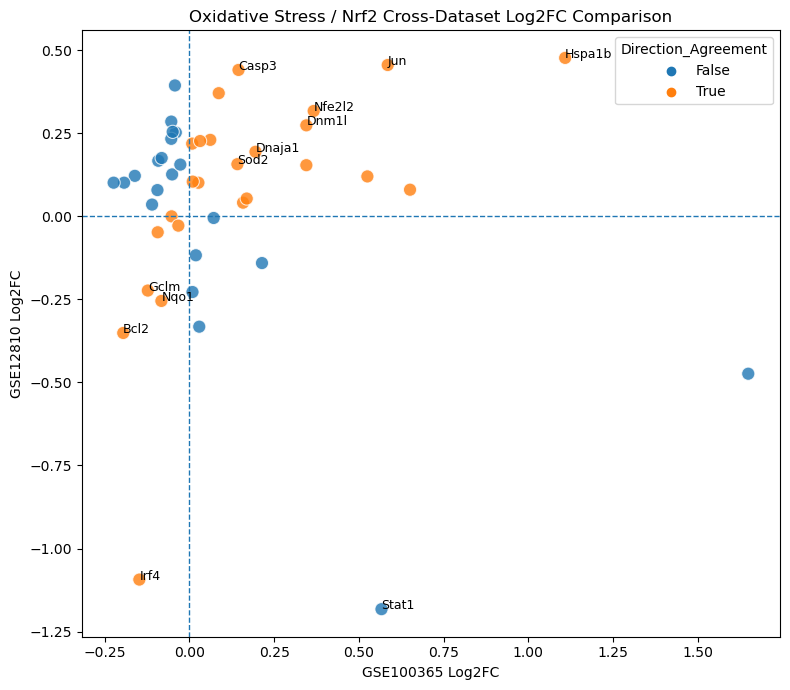

In [74]:
# ----------------------------
# Oxidative/Nrf2 cross-dataset Log2FC scatterplot
# ----------------------------

plt.figure(figsize=(8, 7))

sns.scatterplot(
    data=cross_oxidative,
    x="GSE100365_Log2FC",
    y="GSE12810_Log2FC",
    hue="Direction_Agreement",
    s=90,
    alpha=0.8
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

# Label key genes
key_genes_to_label = [
    "Jun", "Hspa1b", "Dnm1l", "Dnaja1", "Sod2", "Nfe2l2",
    "Casp3", "Bcl2", "Nqo1", "Gclm", "Stat1", "Irf4"
]

for _, row in cross_oxidative.iterrows():
    if row["Gene"] in key_genes_to_label:
        plt.text(
            row["GSE100365_Log2FC"],
            row["GSE12810_Log2FC"],
            row["Gene"],
            fontsize=9
        )

plt.title("Oxidative Stress / Nrf2 Cross-Dataset Log2FC Comparison")
plt.xlabel("GSE100365 Log2FC")
plt.ylabel("GSE12810 Log2FC")

plt.tight_layout()
plt.show()

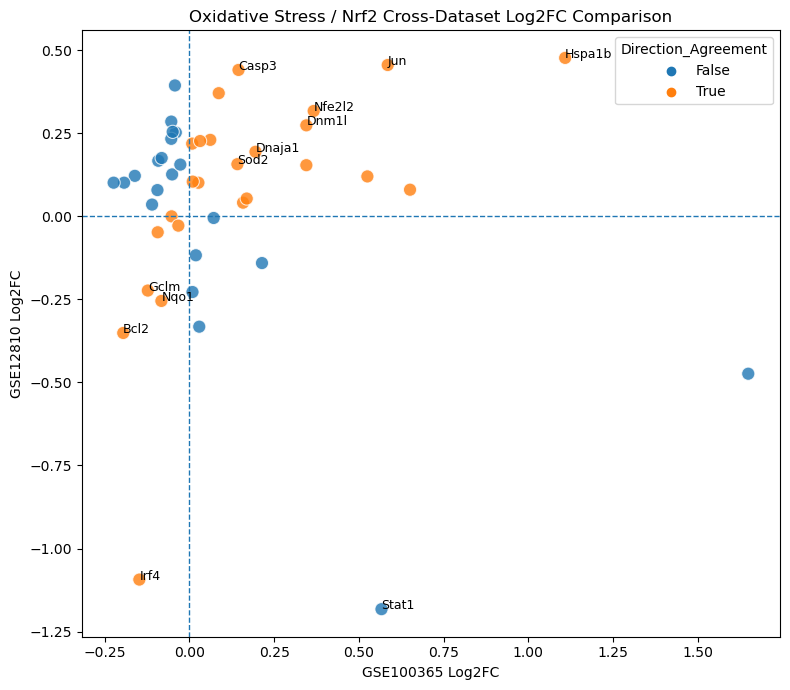

Oxidative/Nrf2 cross-dataset scatterplot saved.


In [75]:
# ----------------------------
# Save oxidative/Nrf2 cross-dataset scatterplot
# ----------------------------

plt.figure(figsize=(8, 7))

sns.scatterplot(
    data=cross_oxidative,
    x="GSE100365_Log2FC",
    y="GSE12810_Log2FC",
    hue="Direction_Agreement",
    s=90,
    alpha=0.8
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

for _, row in cross_oxidative.iterrows():
    if row["Gene"] in key_genes_to_label:
        plt.text(
            row["GSE100365_Log2FC"],
            row["GSE12810_Log2FC"],
            row["Gene"],
            fontsize=9
        )

plt.title("Oxidative Stress / Nrf2 Cross-Dataset Log2FC Comparison")
plt.xlabel("GSE100365 Log2FC")
plt.ylabel("GSE12810 Log2FC")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "GSE100365_GSE12810_oxidative_Nrf2_Log2FC_scatterplot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Oxidative/Nrf2 cross-dataset scatterplot saved.")

### Oxidative Stress / Nrf2 Cross-Dataset Scatterplot Interpretation

The oxidative stress/Nrf2 cross-dataset scatterplot compares Log2FC values for selected stress-response, antioxidant defense, mitochondrial, apoptosis, inflammatory, and Nrf2-related genes shared between GSE100365 and GSE12810. Genes in the upper-right and lower-left quadrants show the same direction of expression change across both datasets.

Several biologically important genes showed consistent directionality, including Hspa1b, Jun, Dnm1l, Nfe2l2, Dnaja1, Sod2, Casp3, Bcl2, Nqo1, Gclm, and Irf4. These genes are associated with heat-shock response, stress-response signaling, mitochondrial dynamics, antioxidant defense, apoptosis regulation, and Nrf2-related oxidative stress pathways.

Although the whole-transcriptome comparison showed approximately 50% direction agreement, the oxidative stress/Nrf2 subset showed stronger pathway-level consistency. This supports the interpretation that GSE12810 partially validates the oxidative stress and cellular stress-response patterns identified in GSE100365, even though the datasets differ in biological context and sample size.

In [76]:
# ----------------------------
# Rank strongest cross-dataset oxidative/Nrf2 validation genes
# ----------------------------

cross_oxidative_ranked = cross_oxidative.copy()

# Absolute fold changes
cross_oxidative_ranked["Abs_GSE100365_Log2FC"] = cross_oxidative_ranked["GSE100365_Log2FC"].abs()
cross_oxidative_ranked["Abs_GSE12810_Log2FC"] = cross_oxidative_ranked["GSE12810_Log2FC"].abs()

# Combined validation score
# Higher = stronger cross-dataset support
cross_oxidative_ranked["Cross_Dataset_Validation_Score"] = (
    cross_oxidative_ranked["Abs_GSE100365_Log2FC"] +
    cross_oxidative_ranked["Abs_GSE12810_Log2FC"]
)

# Prioritize genes that agree in direction
cross_oxidative_ranked["Direction_Agreement_Bonus"] = cross_oxidative_ranked["Direction_Agreement"].astype(int)

cross_oxidative_ranked["Final_Validation_Score"] = (
    cross_oxidative_ranked["Cross_Dataset_Validation_Score"] +
    cross_oxidative_ranked["Direction_Agreement_Bonus"]
)

# Sort by direction agreement first, then final score
cross_oxidative_ranked = cross_oxidative_ranked.sort_values(
    ["Direction_Agreement", "Final_Validation_Score"],
    ascending=[False, False]
)

cross_oxidative_ranked[
    [
        "Gene",
        "GSE100365_Log2FC",
        "GSE12810_Log2FC",
        "GSE100365_p_value",
        "GSE12810_p_value",
        "GSE100365_Direction",
        "GSE12810_Direction",
        "Direction_Agreement",
        "Final_Validation_Score"
    ]
].head(25)

,Gene,GSE100365_Log2FC,GSE12810_Log2FC,GSE100365_p_value,GSE12810_p_value,GSE100365_Direction,GSE12810_Direction,Direction_Agreement,Final_Validation_Score
10084,Hspa1b,1.108333,0.476502,0.000017,0.129344,Up,Up,True,2.584835
10508,Irf4,-0.147500,-1.093334,0.648961,0.000603,Down,Down,True,2.240834
10640,Jun,0.585000,0.455094,0.008992,0.000851,Up,Up,True,2.040094
10083,Hspa1a,0.650833,0.079858,0.018219,0.514436,Up,Up,True,1.730692
12917,Nfe2l2,0.366667,0.316814,0.318489,0.210650,Up,Up,True,1.683481
9479,Gpx3,0.525000,0.119855,0.180831,0.898938,Up,Up,True,1.644855
7112,Dnm1l,0.345000,0.273567,0.000001,0.220453,Up,Up,True,1.618567
4861,Casp3,0.145000,0.440267,0.107170,0.086258,Up,Up,True,1.585267
4164,Bcl2,-0.195000,-0.351253,0.008283,0.212592,Down,Down,True,1.546253
4867,Casp9,0.345000,0.153650,0.000408,0.601242,Up,Up,True,1.498650


In [77]:
# ----------------------------
# Save ranked cross-dataset oxidative/Nrf2 validation table
# ----------------------------

cross_oxidative_ranked.to_csv(
    os.path.join(output_dir, "GSE100365_GSE12810_ranked_oxidative_Nrf2_validation_genes.csv"),
    index=False
)

print("Ranked oxidative/Nrf2 cross-dataset validation table saved.")

Ranked oxidative/Nrf2 cross-dataset validation table saved.


### Ranked Cross-Dataset Oxidative Stress/Nrf2 Validation

To identify the strongest cross-dataset validation genes, oxidative stress/Nrf2-related genes were ranked using a combined validation score based on fold-change magnitude in both GSE100365 and GSE12810, with an added bonus for agreement in direction of expression change. This approach prioritized genes that showed consistent expression behavior across both datasets.

The strongest validated genes included Hspa1b, Irf4, Jun, Nfe2l2, Dnm1l, Casp3, Bcl2, Dnaja1, Gclm, Nqo1, Sod2, Hsp90aa1, Pink1, Dnaja2, and Sirt3. These genes represent several biologically relevant categories, including heat-shock response, Nrf2-related antioxidant regulation, mitochondrial stress, apoptosis regulation, and inflammatory/stress signaling.

These findings suggest that although GSE12810 does not globally replicate all transcriptomic changes from GSE100365, it provides partial pathway-level validation for oxidative stress and cellular stress-response mechanisms associated with noise-induced hearing loss.

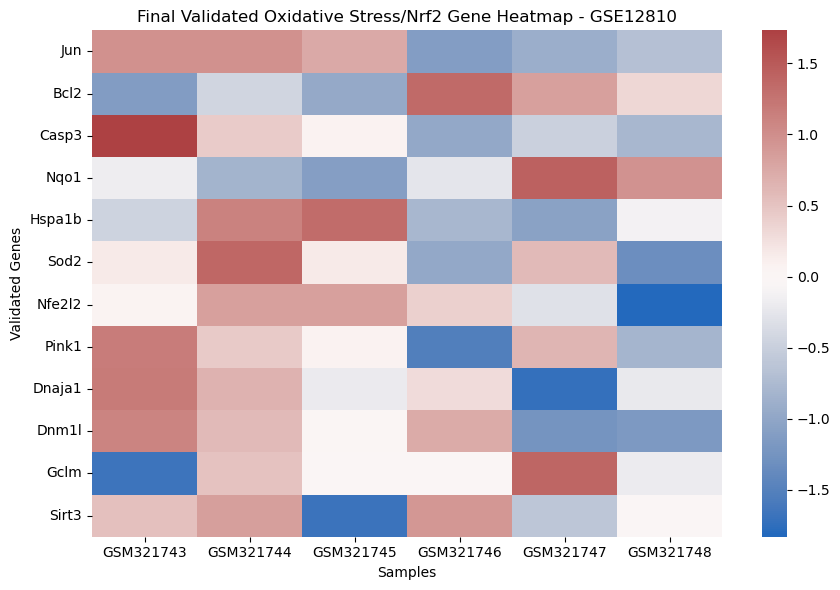

In [78]:
# ----------------------------
# Final validation heatmap: strongest cross-dataset oxidative/Nrf2 genes
# ----------------------------

final_validated_genes = [
    "Hspa1b", "Jun", "Dnm1l", "Nfe2l2", "Casp3", "Bcl2",
    "Dnaja1", "Sod2", "Gclm", "Nqo1", "Pink1", "Sirt3"
]

final_validation_probes = best_oxidative_validation[
    best_oxidative_validation["Target_Gene"].isin(final_validated_genes)
]["Probe_ID"].tolist()

final_validation_expr = expr_df.loc[final_validation_probes].copy()

probe_to_gene_final = best_oxidative_validation.set_index("Probe_ID")["Target_Gene"].to_dict()
final_validation_expr.index = final_validation_expr.index.map(probe_to_gene_final)

sample_order = noise_samples + control_samples
final_validation_expr = final_validation_expr[sample_order]

final_validation_expr_z = final_validation_expr.sub(final_validation_expr.mean(axis=1), axis=0)
final_validation_expr_z = final_validation_expr_z.div(final_validation_expr.std(axis=1), axis=0)

plt.figure(figsize=(9, 6))

sns.heatmap(
    final_validation_expr_z,
    cmap="vlag",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Final Validated Oxidative Stress/Nrf2 Gene Heatmap - GSE12810")
plt.xlabel("Samples")
plt.ylabel("Validated Genes")

plt.tight_layout()
plt.show()

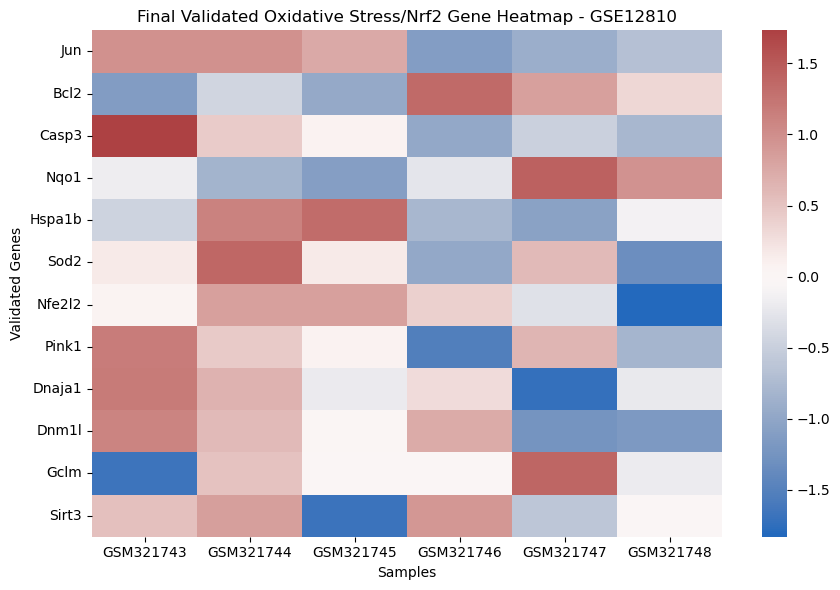

Final validation heatmap saved.


In [79]:
# ----------------------------
# Save final validation heatmap
# ----------------------------

plt.figure(figsize=(9, 6))

sns.heatmap(
    final_validation_expr_z,
    cmap="vlag",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Final Validated Oxidative Stress/Nrf2 Gene Heatmap - GSE12810")
plt.xlabel("Samples")
plt.ylabel("Validated Genes")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "GSE12810_final_validated_oxidative_Nrf2_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final validation heatmap saved.")

### Final Validated Oxidative Stress/Nrf2 Gene Heatmap

A final heatmap was generated using the strongest cross-dataset oxidative stress/Nrf2-related validation genes, including Hspa1b, Jun, Dnm1l, Nfe2l2, Casp3, Bcl2, Dnaja1, Sod2, Gclm, Nqo1, Pink1, and Sirt3. These genes were selected because they showed cross-dataset directional agreement between GSE100365 and GSE12810 and represent key biological categories involved in NIHL, including heat-shock response, mitochondrial stress, antioxidant defense, apoptosis regulation, and Nrf2-related oxidative stress signaling.

The heatmap shows partial separation between noise-exposed and control samples. Several genes, including Jun, Hspa1b, Dnm1l, and Nfe2l2, show stronger expression patterns in noise-exposed samples, while Bcl2 shows an opposite pattern. Although the separation is not perfect, the expression patterns support the interpretation that GSE12810 provides pathway-level validation for oxidative stress and cellular stress-response mechanisms identified in GSE100365.

In [80]:
# ----------------------------
# Final validated gene summary table
# ----------------------------

final_validated_gene_set = cross_oxidative_ranked[
    cross_oxidative_ranked["Gene"].isin(final_validated_genes)
].copy()

# Add biological category labels
gene_category_map = {
    "Hspa1b": "Heat shock / cellular stress response",
    "Jun": "Stress-response transcription factor",
    "Dnm1l": "Mitochondrial dynamics / mitochondrial stress",
    "Nfe2l2": "Nrf2 pathway regulation",
    "Casp3": "Apoptosis / cell death",
    "Bcl2": "Apoptosis regulation / cell survival",
    "Dnaja1": "Chaperone / cellular stress response",
    "Sod2": "Mitochondrial antioxidant defense",
    "Gclm": "Glutathione synthesis / antioxidant defense",
    "Nqo1": "Nrf2-associated antioxidant response",
    "Pink1": "Mitochondrial quality control",
    "Sirt3": "Mitochondrial stress / redox regulation"
}

final_validated_gene_set["Biological_Category"] = final_validated_gene_set["Gene"].map(gene_category_map)

final_validated_gene_set = final_validated_gene_set[
    [
        "Gene",
        "Biological_Category",
        "GSE100365_Log2FC",
        "GSE12810_Log2FC",
        "GSE100365_p_value",
        "GSE12810_p_value",
        "GSE100365_Direction",
        "GSE12810_Direction",
        "Direction_Agreement",
        "Final_Validation_Score"
    ]
].sort_values("Final_Validation_Score", ascending=False)

final_validated_gene_set

,Gene,Biological_Category,GSE100365_Log2FC,GSE12810_Log2FC,GSE100365_p_value,GSE12810_p_value,GSE100365_Direction,GSE12810_Direction,Direction_Agreement,Final_Validation_Score
10084,Hspa1b,Heat shock / cellular stress response,1.108333,0.476502,0.000017,0.129344,Up,Up,True,2.584835
10640,Jun,Stress-response transcription factor,0.585000,0.455094,0.008992,0.000851,Up,Up,True,2.040094
12917,Nfe2l2,Nrf2 pathway regulation,0.366667,0.316814,0.318489,0.210650,Up,Up,True,1.683481
7112,Dnm1l,Mitochondrial dynamics / mitochondrial stress,0.345000,0.273567,0.000001,0.220453,Up,Up,True,1.618567
4861,Casp3,Apoptosis / cell death,0.145000,0.440267,0.107170,0.086258,Up,Up,True,1.585267
4164,Bcl2,Apoptosis regulation / cell survival,-0.195000,-0.351253,0.008283,0.212592,Down,Down,True,1.546253
7054,Dnaja1,Chaperone / cellular stress response,0.195000,0.194013,0.001875,0.215468,Up,Up,True,1.389013
8678,Gclm,Glutathione synthesis / antioxidant defense,-0.122500,-0.223581,0.050096,0.404518,Down,Down,True,1.346081
13146,Nqo1,Nrf2-associated antioxidant response,-0.082500,-0.254880,0.622854,0.089263,Down,Down,True,1.337380
17044,Sod2,Mitochondrial antioxidant defense,0.141667,0.156665,0.034185,0.194180,Up,Up,True,1.298331


In [81]:
# ----------------------------
# Save final validated gene summary table
# ----------------------------

final_validated_gene_set.to_csv(
    os.path.join(output_dir, "FINAL_validated_oxidative_Nrf2_gene_summary.csv"),
    index=False
)

print("Final validated oxidative/Nrf2 gene summary saved.")

Final validated oxidative/Nrf2 gene summary saved.


### Cross-Dataset Validation of Oxidative Stress/Nrf2-Related Genes

To evaluate whether oxidative stress and Nrf2-related expression patterns identified in GSE100365 were reproducible in an independent NIHL-related dataset, a cross-dataset comparison was performed using GSE12810. Each dataset was collapsed to the best probe per gene based on p-value, and shared genes were merged by gene symbol. Across the full transcriptome, 20,226 overlapping genes were identified between GSE100365 and GSE12810. However, global direction agreement was approximately 50%, indicating that the two datasets did not show strong whole-transcriptome replication.

Because the datasets differ in biological context, tissue focus, and experimental timing, targeted pathway-level validation was then performed using oxidative stress, antioxidant defense, mitochondrial stress, apoptosis, heat-shock, inflammatory, and Nrf2-related genes. Within this targeted gene set, 46 genes overlapped between datasets, and 25 showed the same direction of expression change, corresponding to 54.35% directional agreement. This represented a modest improvement over the global transcriptome background.

A final validated gene set was selected based on cross-dataset directional agreement and biological relevance. The strongest validated genes included Hspa1b, Jun, Nfe2l2, Dnm1l, Casp3, Bcl2, Dnaja1, Gclm, Nqo1, Sod2, Pink1, and Sirt3. These genes represent several major biological categories involved in NIHL, including heat-shock response, stress-response transcriptional regulation, Nrf2-mediated antioxidant signaling, mitochondrial dysfunction, apoptosis regulation, and redox homeostasis.

These findings suggest that GSE12810 provides partial pathway-level validation for oxidative stress and cellular stress-response mechanisms identified in GSE100365. Although GSE12810 did not globally replicate all transcriptomic changes from the discovery dataset, the recurrence of biologically relevant oxidative stress/Nrf2-related genes supports the interpretation that NIHL involves coordinated stress-response, mitochondrial, antioxidant, and apoptosis-related molecular changes.

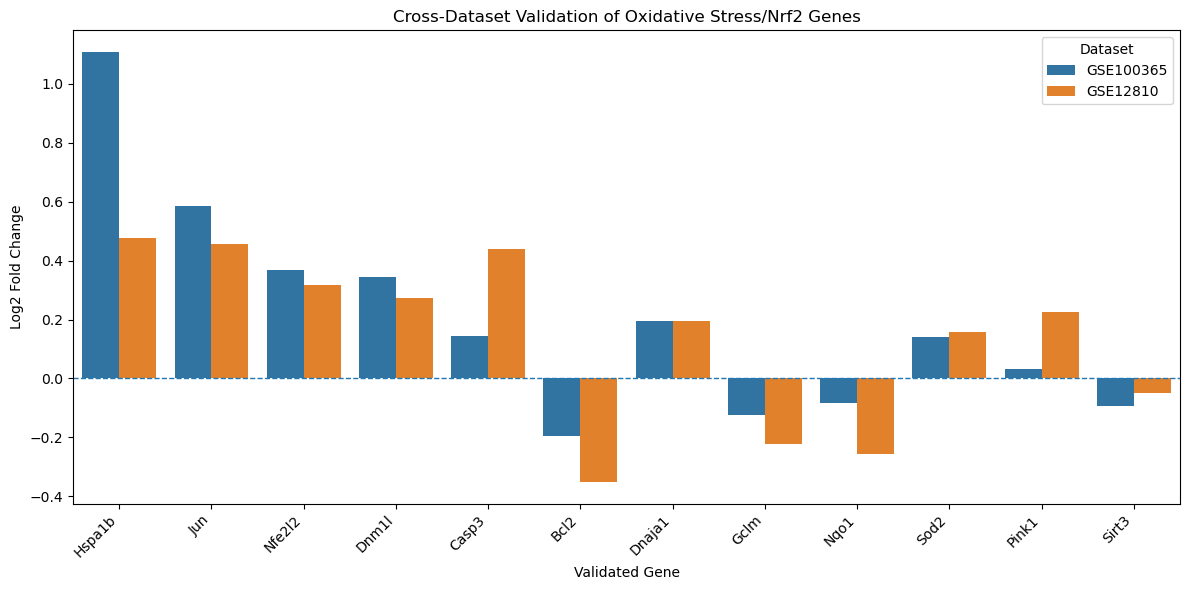

In [82]:
# ----------------------------
# Final validated gene Log2FC comparison bar plot
# ----------------------------

plot_df = final_validated_gene_set[
    [
        "Gene",
        "GSE100365_Log2FC",
        "GSE12810_Log2FC"
    ]
].copy()

# Convert wide format to long format for plotting
plot_long = plot_df.melt(
    id_vars="Gene",
    value_vars=["GSE100365_Log2FC", "GSE12810_Log2FC"],
    var_name="Dataset",
    value_name="Log2FC"
)

# Clean dataset names
plot_long["Dataset"] = plot_long["Dataset"].replace({
    "GSE100365_Log2FC": "GSE100365",
    "GSE12810_Log2FC": "GSE12810"
})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_long,
    x="Gene",
    y="Log2FC",
    hue="Dataset"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Cross-Dataset Validation of Oxidative Stress/Nrf2 Genes")
plt.xlabel("Validated Gene")
plt.ylabel("Log2 Fold Change")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

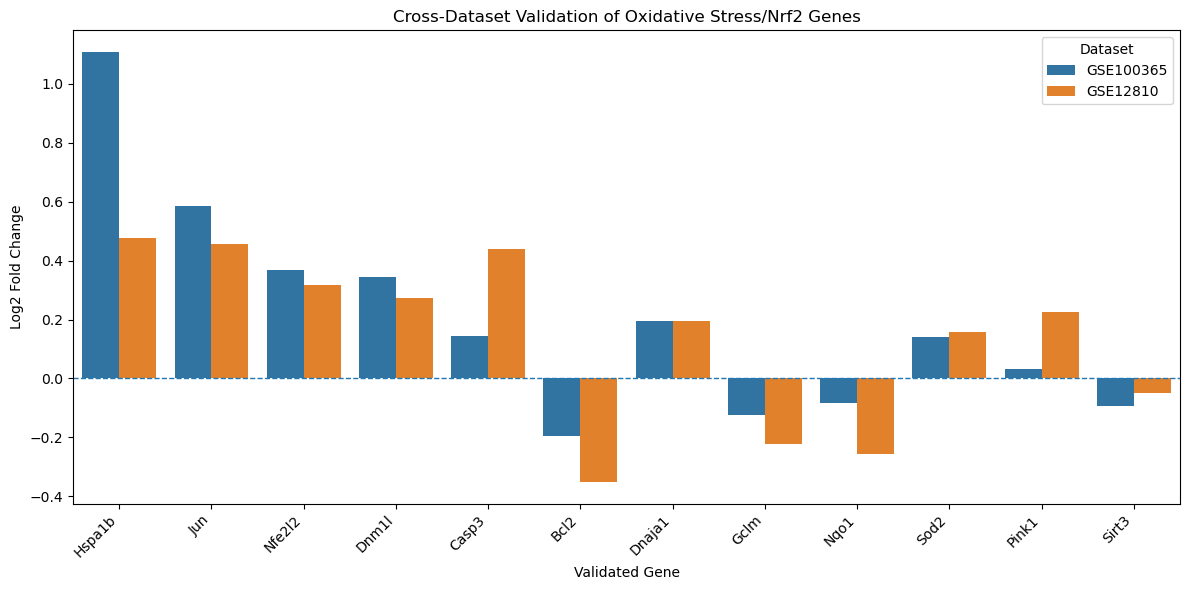

Final cross-dataset validated gene bar plot saved.


In [83]:
# ----------------------------
# Save final validated gene Log2FC bar plot
# ----------------------------

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_long,
    x="Gene",
    y="Log2FC",
    hue="Dataset"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Cross-Dataset Validation of Oxidative Stress/Nrf2 Genes")
plt.xlabel("Validated Gene")
plt.ylabel("Log2 Fold Change")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "FINAL_cross_dataset_validated_gene_Log2FC_barplot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final cross-dataset validated gene bar plot saved.")

### Final Cross-Dataset Validated Gene Bar Plot

A final bar plot was generated to compare Log2FC values for the 12 strongest oxidative stress/Nrf2-related validation genes across GSE100365 and GSE12810. These genes were selected because they showed directional agreement across both datasets and represented biologically relevant categories involved in NIHL, including heat-shock response, Nrf2 signaling, mitochondrial stress, antioxidant defense, apoptosis regulation, and cellular stress response.

The plot shows that Hspa1b, Jun, Nfe2l2, Dnm1l, Casp3, Dnaja1, Sod2, and Pink1 were upregulated in both datasets, while Bcl2, Gclm, Nqo1, and Sirt3 were downregulated in both datasets. Although the magnitude of expression change differed between datasets, the shared direction of change supports partial cross-dataset validation of oxidative stress and cellular stress-response mechanisms associated with noise-induced hearing loss.

In [84]:
# ----------------------------
# Create final output folders
# ----------------------------

final_tables_dir = os.path.join(output_dir, "Final_Tables")
final_figures_dir = os.path.join(output_dir, "Final_Figures")

os.makedirs(final_tables_dir, exist_ok=True)
os.makedirs(final_figures_dir, exist_ok=True)

print("Final tables folder:", final_tables_dir)
print("Final figures folder:", final_figures_dir)

Final tables folder: GSE12810_Validation_Analysis\Final_Tables
Final figures folder: GSE12810_Validation_Analysis\Final_Figures


In [85]:
# ----------------------------
# Save final important tables
# ----------------------------

de_annotated.to_csv(
    os.path.join(final_tables_dir, "GSE12810_all_DE_results_annotated.csv"),
    index=False
)

ranked_degs.to_csv(
    os.path.join(final_tables_dir, "GSE12810_relaxed_ranked_DEGs.csv"),
    index=False
)

best_candidate_validation.to_csv(
    os.path.join(final_tables_dir, "GSE12810_Dataset1_candidate_validation.csv"),
    index=False
)

best_oxidative_validation.to_csv(
    os.path.join(final_tables_dir, "GSE12810_oxidative_stress_Nrf2_validation.csv"),
    index=False
)

cross_dataset.to_csv(
    os.path.join(final_tables_dir, "GSE100365_GSE12810_all_gene_cross_dataset_comparison.csv"),
    index=False
)

cross_oxidative.to_csv(
    os.path.join(final_tables_dir, "GSE100365_GSE12810_oxidative_Nrf2_cross_dataset_comparison.csv"),
    index=False
)

cross_oxidative_ranked.to_csv(
    os.path.join(final_tables_dir, "GSE100365_GSE12810_ranked_oxidative_Nrf2_validation.csv"),
    index=False
)

final_validated_gene_set.to_csv(
    os.path.join(final_tables_dir, "FINAL_validated_oxidative_Nrf2_gene_summary.csv"),
    index=False
)

print("All final tables saved.")

All final tables saved.


In [86]:
# ----------------------------
# Save Dataset 2 validation summary
# ----------------------------

summary_text = """
GSE12810 Dataset 2 Validation Summary

Dataset:
GSE12810 was used as an independent validation dataset for the NIHL oxidative stress/Nrf2 bioinformatics project.

Main dataset structure:
- 6 total samples
- 3 noise-exposed samples
- 3 control/unexposed samples
- 45,101 probes
- Platform: GPL1261 Affymetrix Mouse Genome 430 2.0 Array

Differential expression:
- Strict FDR-significant probes: 0
- Relaxed ranked DE probes: 996 annotated probes
- Volcano trend probes:
  - Upregulated trend: 653
  - Downregulated trend: 492
  - Not significant: 43,956

Oxidative stress/Nrf2 validation:
- Oxidative stress/Nrf2-related probe hits: 280
- Unique target genes found: 48
- Validation categories:
  - Strong validation trend: 6
  - Fold-change trend only: 10
  - Statistical trend only: 1
  - Weak/no validation trend: 31

Cross-dataset comparison:
- GSE100365 unique genes: 21,722
- GSE12810 unique genes: 21,815
- Overlapping genes: 20,226
- Whole-transcriptome direction agreement:
  - True: 10,116 genes
  - False: 10,110 genes
  - Percent agreement: ~50.01%

Oxidative/Nrf2 cross-dataset comparison:
- Overlapping oxidative/Nrf2 genes: 46
- Direction agreement:
  - True: 25 genes
  - False: 21 genes
  - Percent agreement: 54.35%

Final validated oxidative/Nrf2 gene set:
Hspa1b, Jun, Nfe2l2, Dnm1l, Casp3, Bcl2, Dnaja1, Gclm, Nqo1, Sod2, Pink1, Sirt3

Overall interpretation:
GSE12810 does not globally replicate all GSE100365 transcriptomic changes, but it provides partial pathway-level validation for oxidative stress, Nrf2-related antioxidant signaling, mitochondrial stress, apoptosis regulation, heat-shock response, and cellular stress-response mechanisms in NIHL.
"""

summary_path = os.path.join(output_dir, "GSE12810_validation_summary.txt")

with open(summary_path, "w") as f:
    f.write(summary_text)

print("Summary saved to:", summary_path)

Summary saved to: GSE12810_Validation_Analysis\GSE12810_validation_summary.txt


In [87]:
# ----------------------------
# Check saved files
# ----------------------------

print("Final tables:")
print(os.listdir(final_tables_dir))

print("\nMain output folder:")
print(os.listdir(output_dir))

Final tables:
['FINAL_validated_oxidative_Nrf2_gene_summary.csv', 'GSE100365_GSE12810_all_gene_cross_dataset_comparison.csv', 'GSE100365_GSE12810_oxidative_Nrf2_cross_dataset_comparison.csv', 'GSE100365_GSE12810_ranked_oxidative_Nrf2_validation.csv', 'GSE12810_all_DE_results_annotated.csv', 'GSE12810_Dataset1_candidate_validation.csv', 'GSE12810_oxidative_stress_Nrf2_validation.csv', 'GSE12810_relaxed_ranked_DEGs.csv']

Main output folder:
['FINAL_cross_dataset_validated_gene_Log2FC_barplot.png', 'Final_Figures', 'Final_Tables', 'FINAL_validated_oxidative_Nrf2_gene_summary.csv', 'GSE100365_GSE12810_cross_dataset_gene_comparison.csv', 'GSE100365_GSE12810_Log2FC_scatterplot.png', 'GSE100365_GSE12810_oxidative_Nrf2_cross_dataset_comparison.csv', 'GSE100365_GSE12810_oxidative_Nrf2_Log2FC_scatterplot.png', 'GSE100365_GSE12810_ranked_oxidative_Nrf2_validation_genes.csv', 'GSE12810_best_candidate_validation.csv', 'GSE12810_best_candidate_validation_labeled.csv', 'GSE12810_Dataset1_candidate_v